# TP2 — Restaurant Recommender System (v2)
### Complete pipeline following the CRISP-DM framework

**Dataset:** UCI Restaurant & Consumer Data (https://archive.ics.uci.edu/dataset/232/restaurant+consumer+data)


## 1. Business Understanding

**Business problem:** A restaurant-discovery platform (Yelp/TripAdvisor-style) wants to increase
engagement and average ticket size by recommending relevant restaurants to each consumer, instead of
showing a generic list sorted by popularity.

**Project goal:** build a recommender system that, given a consumer (new or existing), returns a
top-N list of relevant restaurants, combining:
- **Content** (restaurant attributes: cuisine, ambience, location, price, proximity) → solves cold-start
  for new restaurants.
- **Past interactions** (food/service/ambience ratings) → improves over time (collaborative filtering).
- **Hybrid** → combines both, plus user-attribute matching, to mitigate cold-start for new users.

**Success metric (offline proxy):** Precision@k and Recall@k on a held-out set of ratings, benchmarked
against a popularity baseline.
**Business metric (hypothetical):** click-through rate on recommendations / conversion to a visit.

**Scope:** (a) a reproducible end-to-end notebook, (b) a serialized final model, (c) a working
deployment (Streamlit).


In [1]:
# Libraries
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, haversine_distances
from sklearn.model_selection import train_test_split
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate
from surprise.model_selection import GridSearchCV as SurpriseGridSearchCV
from collections import defaultdict

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)


## 2. Data Understanding

The UCI dataset comes as **9 CSVs**. All 9 are loaded and used in this version:

| File | Content | Relationship | Used for |
|---|---|---|---|
| `rating_final.csv` | (userID, placeID, rating, food_rating, service_rating) | interactions | target (composite) |
| `geoplaces2.csv` | restaurant attributes + lat/long | 1 row per placeID | content + geo similarity |
| `chefmozcuisine.csv` | cuisine type per restaurant | one-to-many | content (multi-hot) |
| `chefmozparking.csv` | parking type | one-to-many | content (multi-hot) |
| `chefmozaccepts.csv` | payment methods accepted | one-to-many | content (multi-hot) |
| `chefmozhours4.csv` | opening hours/days | one-to-many | content (shift flags) |
| `userprofile.csv` | consumer attributes (19 cols) | 1 row per userID | user-side content (full) |
| `usercuisine.csv` | cuisine preferences per user | one-to-many | user-side content |
| `userpayment.csv` | payment preferences per user | one-to-many | user-side content |

**Encoding note:** `geoplaces2.csv` contains Spanish-language characters → requires `encoding='latin-1'`.

**Missing-value note:** this dataset encodes missing values as the literal string `"?"`, not NaN —
this must be handled before any encoding step, or `"?"` becomes its own fake category.


In [2]:
DATA_DIR = "./data"  # <-- set this to the local path of the 9 CSVs

ratings      = pd.read_csv(f"{DATA_DIR}/rating_final.csv")
places       = pd.read_csv(f"{DATA_DIR}/geoplaces2.csv", encoding="latin-1")
cuisine      = pd.read_csv(f"{DATA_DIR}/chefmozcuisine.csv")
parking      = pd.read_csv(f"{DATA_DIR}/chefmozparking.csv")
accepts      = pd.read_csv(f"{DATA_DIR}/chefmozaccepts.csv")
hours        = pd.read_csv(f"{DATA_DIR}/chefmozhours4.csv")
users        = pd.read_csv(f"{DATA_DIR}/userprofile.csv")
usercuisine  = pd.read_csv(f"{DATA_DIR}/usercuisine.csv")
userpayment  = pd.read_csv(f"{DATA_DIR}/userpayment.csv")

# Normalize casing/whitespace on every categorical text column RIGHT HERE, at load time — this
# is what fixes the "VISA" vs "Visa" duplicate-category bug found in Section 2c's audit. Doing it
# here (rather than later, in Section 3's multi-hot cells) guarantees Section 2c's EDA and
# Section 3's content/profile features are both built from the same clean categories, regardless
# of which cells get run/rerun later.
cuisine["Rcuisine"] = cuisine["Rcuisine"].str.strip().str.title()
parking["parking_lot"] = parking["parking_lot"].str.strip().str.title()
accepts["Rpayment"] = accepts["Rpayment"].str.strip().str.title()
usercuisine["Rcuisine"] = usercuisine["Rcuisine"].str.strip().str.title()
userpayment["Upayment"] = userpayment["Upayment"].str.strip().str.title()

for col in ["alcohol", "smoking_area", "dress_code", "price", "Rambience",
            "accessibility", "franchise", "area"]:
    notna = places[col].notna() & (places[col] != "?")
    places.loc[notna, col] = places.loc[notna, col].str.strip().str.title()

print("ratings:", ratings.shape)
print("places:", places.shape)
print("cuisine:", cuisine.shape)
print("parking:", parking.shape)
print("accepts:", accepts.shape)
print("hours:", hours.shape)
print("users:", users.shape)
print("usercuisine:", usercuisine.shape)
print("userpayment:", userpayment.shape)
ratings.head()


ratings: (1161, 5)
places: (130, 21)
cuisine: (916, 2)
parking: (702, 2)
accepts: (1314, 2)
hours: (2339, 3)
users: (138, 19)
usercuisine: (330, 2)
userpayment: (177, 2)


,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


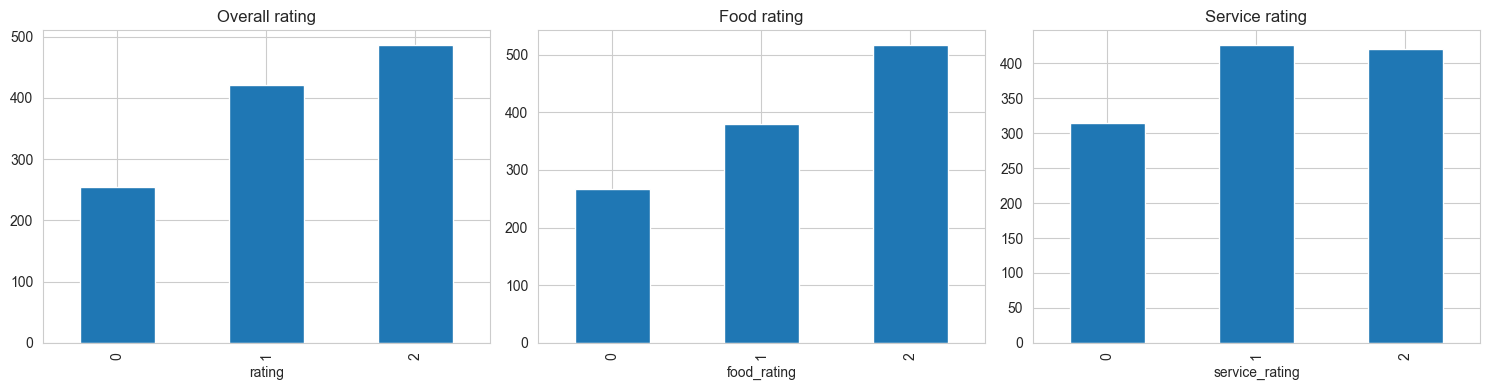

Unique users: 138
Unique restaurants: 130
Total interactions: 1161
User-item matrix density: 6.472%

Rating distribution (proportions):
rating
0    0.218777
1    0.362618
2    0.418605
Name: proportion, dtype: float64

Correlation between the 3 rating dimensions:
                  rating  food_rating  service_rating
rating          1.000000     0.714855        0.690757
food_rating     0.714855     1.000000        0.647177
service_rating  0.690757     0.647177        1.000000


In [3]:
# EDA — now covering all 3 rating dimensions, not just the overall rating
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Overall rating")
ratings["food_rating"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Food rating")
ratings["service_rating"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Service rating")
plt.tight_layout()
plt.show()

print("Unique users:", ratings.userID.nunique())
print("Unique restaurants:", ratings.placeID.nunique())
print("Total interactions:", len(ratings))
print("User-item matrix density: {:.3%}".format(len(ratings) / (ratings.userID.nunique() * ratings.placeID.nunique())))
print()
print("Rating distribution (proportions):")
print(ratings["rating"].value_counts(normalize=True).sort_index())
print()
print("Correlation between the 3 rating dimensions:")
print(ratings[["rating", "food_rating", "service_rating"]].corr())


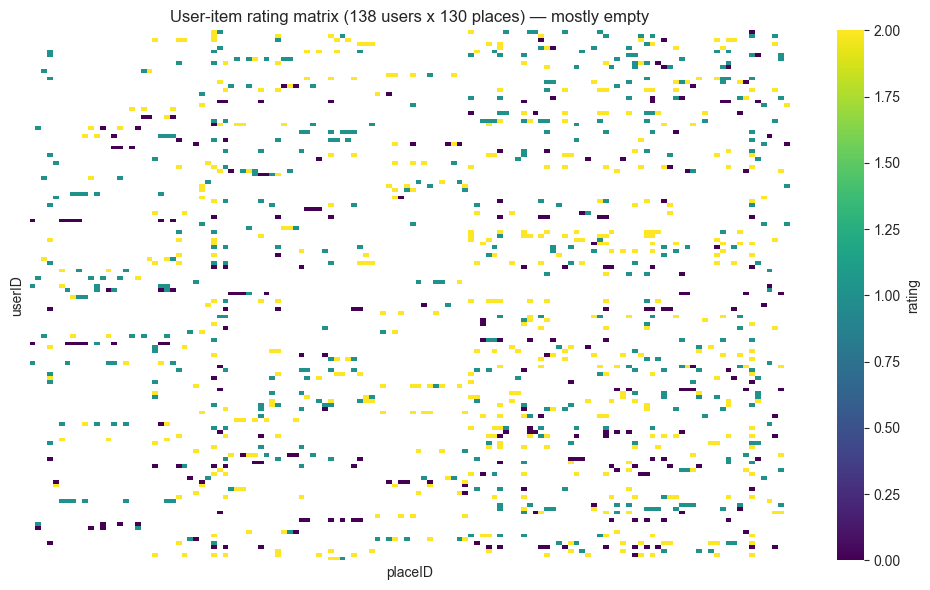

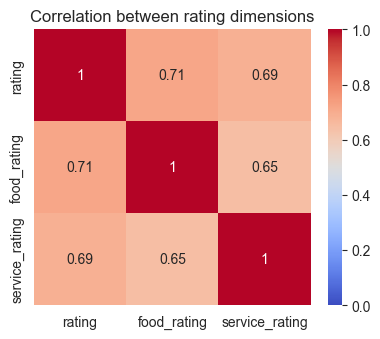

In [4]:
# Visualize the sparsity directly: the user-item interaction matrix as a heatmap.
# Density print already showed ~6.5%; seeing the actual gaps makes it concrete.
interaction_matrix = ratings.pivot_table(index="userID", columns="placeID", values="rating", aggfunc="mean")

plt.figure(figsize=(10, 6))
sns.heatmap(interaction_matrix, cmap="viridis", cbar_kws={"label": "rating"}, mask=interaction_matrix.isna())
plt.title(f"User-item rating matrix ({interaction_matrix.shape[0]} users x {interaction_matrix.shape[1]} places) — mostly empty")
plt.xlabel("placeID"); plt.ylabel("userID")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

# Correlation between the 3 rating dimensions, as a heatmap instead of a printed table
plt.figure(figsize=(4, 3.5))
sns.heatmap(ratings[["rating", "food_rating", "service_rating"]].corr(), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation between rating dimensions")
plt.tight_layout()
plt.show()


## 2b. Deeper EDA on the other 8 raw tables

Before merging anything in Section 3, it's worth actually looking at each source table on its own —
distributions, missingness, coverage relative to `ratings` — rather than only checking shapes. This is
what Section 3's design decisions (multi-hot vs. discard, how to handle `"?"`, which columns to keep)
were based on, and it's worth seeing the evidence directly instead of taking it on faith.

### `geoplaces2.csv` — restaurant attributes


Columns: ['placeID', 'latitude', 'longitude', 'the_geom_meter', 'name', 'address', 'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area', 'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise', 'area', 'other_services']

Missing-value marker ('?') count per column:
fax        130
url        116
zip         74
country     28
address     27
state       18
city        18
dtype: int64


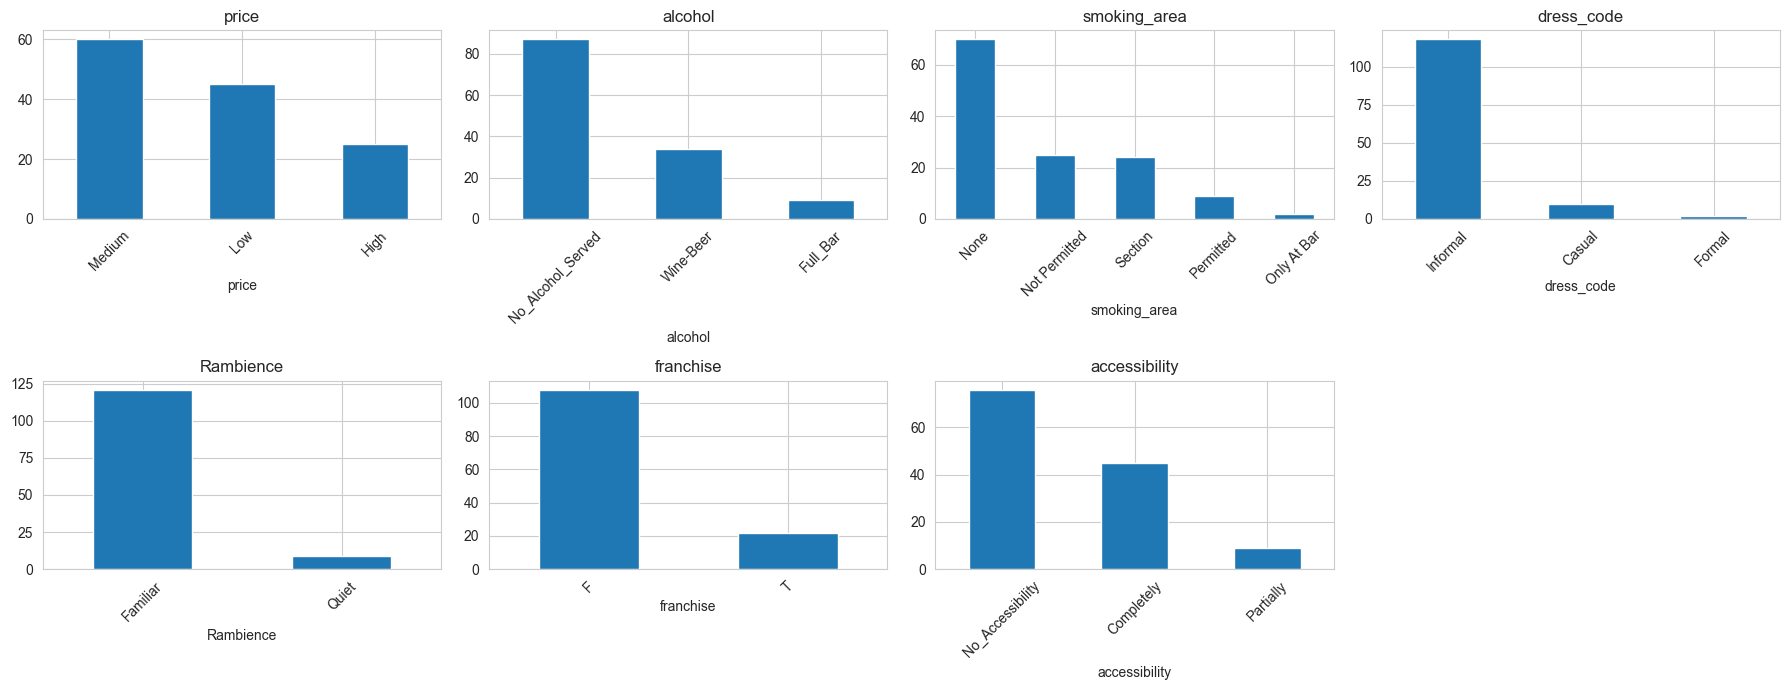


City / state coverage:
city
San Luis Potosi    64
?                  18
Cuernavaca         15
victoria           10
san luis potosi     5
Jiutepec            4
victoria            2
Ciudad Victoria     2
Soledad             2
Cd Victoria         1
Name: count, dtype: int64

state
SLP                50
Morelos            19
?                  18
San Luis Potosi    14
tamaulipas          9
Tamaulipas          7
san luis potosi     4
S.L.P.              2
slp                 2
mexico              2
Name: count, dtype: int64


In [5]:
print("Columns:", list(places.columns))
print("\nMissing-value marker ('?') count per column:")
print((places == "?").sum()[lambda s: s > 0].sort_values(ascending=False))

cat_cols_to_plot = ["price", "alcohol", "smoking_area", "dress_code", "Rambience", "franchise", "accessibility"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, cat_cols_to_plot):
    places[col].value_counts(dropna=False).plot(kind="bar", ax=ax, title=col)
    ax.tick_params(axis="x", rotation=45)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

print("\nCity / state coverage:")
print(places["city"].value_counts().head(10))
print()
print(places["state"].value_counts().head(10))


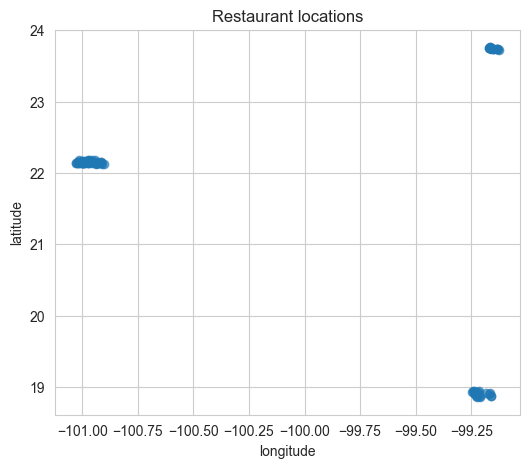

Restaurants with valid coordinates: 130 / 130


In [6]:
# Where are the restaurants, geographically? Useful for sanity-checking the geo-similarity feature
# built in Section 3.4 — if everything is clustered in 1-2 cities, geo distance carries little signal.
plt.figure(figsize=(6, 5))
plt.scatter(places["longitude"], places["latitude"], alpha=0.6)
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title("Restaurant locations")
plt.show()

valid_coords = places[["latitude", "longitude"]].apply(pd.to_numeric, errors="coerce").dropna()
print(f"Restaurants with valid coordinates: {len(valid_coords)} / {len(places)}")


### `chefmozcuisine.csv` — restaurant cuisine tags (one-to-many)


Rows: 916 | Unique restaurants tagged: 769 | Unique cuisine labels: 59

Cuisine tags per restaurant — distribution:
1    659
2     87
3     18
4      2
6      2
9      1
Name: count, dtype: int64


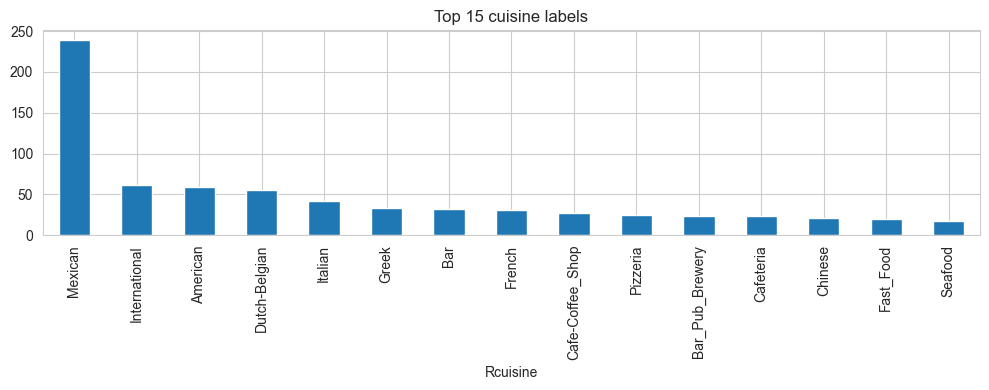


Restaurants with NO cuisine tag at all: 35 / 130


In [7]:
print(f"Rows: {len(cuisine)} | Unique restaurants tagged: {cuisine['placeID'].nunique()} | "
      f"Unique cuisine labels: {cuisine['Rcuisine'].nunique()}")

cuisines_per_place = cuisine.groupby("placeID").size()
print("\nCuisine tags per restaurant — distribution:")
print(cuisines_per_place.value_counts().sort_index())

plt.figure(figsize=(10, 4))
cuisine["Rcuisine"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 cuisine labels")
plt.tight_layout()
plt.show()

restaurants_without_cuisine = set(places["placeID"]) - set(cuisine["placeID"])
print(f"\nRestaurants with NO cuisine tag at all: {len(restaurants_without_cuisine)} / {places['placeID'].nunique()}")


### `chefmozparking.csv` and `chefmozaccepts.csv` — parking & payment options (one-to-many)


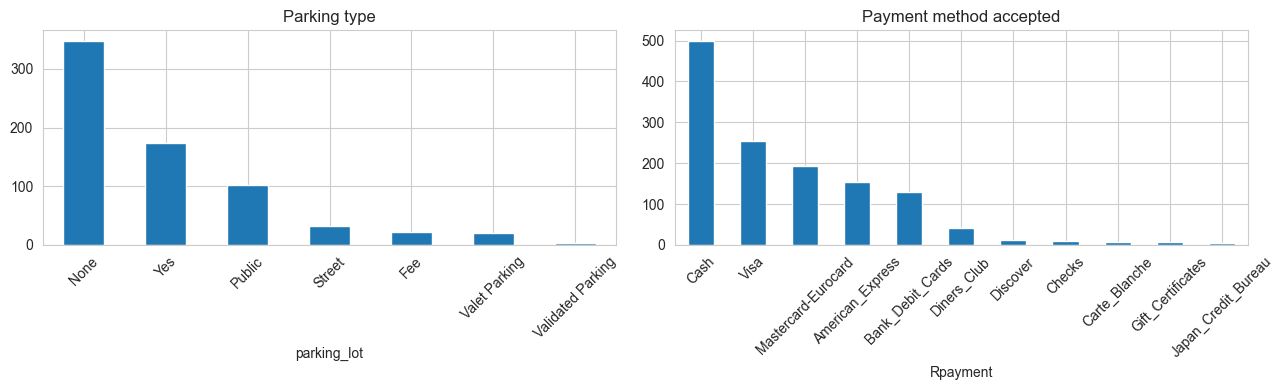

Restaurants with a parking entry: 675 / 130
Restaurants with a payment entry: 615 / 130
Avg payment methods accepted per restaurant: 2.14


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
parking["parking_lot"].value_counts().plot(kind="bar", ax=axes[0], title="Parking type")
accepts["Rpayment"].value_counts().plot(kind="bar", ax=axes[1], title="Payment method accepted")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Restaurants with a parking entry: {parking['placeID'].nunique()} / {places['placeID'].nunique()}")
print(f"Restaurants with a payment entry: {accepts['placeID'].nunique()} / {places['placeID'].nunique()}")
print(f"Avg payment methods accepted per restaurant: {accepts.groupby('placeID').size().mean():.2f}")


### `chefmozhours4.csv` — opening hours (one-to-many, before the shift-extraction in 3.2)


In [9]:
print(f"Rows: {len(hours)} | Restaurants covered: {hours['placeID'].nunique()} / {places['placeID'].nunique()}")
print("\nSample raw hours/days strings:")
print(hours[["placeID", "hours", "days"]].head(5).to_string(index=False))

# How many restaurants have multiple time-range rows (i.e. split shifts already in the raw data)?
rows_per_place = hours.groupby("placeID").size()
print("\nRows per restaurant — distribution (some restaurants log breakfast/lunch/dinner as separate rows):")
print(rows_per_place.value_counts().sort_index())


Rows: 2339 | Restaurants covered: 694 / 130

Sample raw hours/days strings:
 placeID        hours                 days
  135111 00:00-23:30; Mon;Tue;Wed;Thu;Fri;
  135111 00:00-23:30;                 Sat;
  135111 00:00-23:30;                 Sun;
  135110 08:00-19:00; Mon;Tue;Wed;Thu;Fri;
  135110 00:00-00:00;                 Sat;

Rows per restaurant — distribution (some restaurants log breakfast/lunch/dinner as separate rows):
2       4
3     599
4      12
6      76
8       1
10      1
12      1
Name: count, dtype: int64


### `userprofile.csv` — consumer demographics (19 columns)


Columns: ['userID', 'latitude', 'longitude', 'smoker', 'drink_level', 'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos', 'birth_year', 'interest', 'personality', 'religion', 'activity', 'color', 'weight', 'budget', 'height']

Missing-value marker ('?') count per column:
hijos               11
transport            7
activity             7
budget               7
ambience             6
dress_preference     5
marital_status       4
smoker               3
dtype: int64


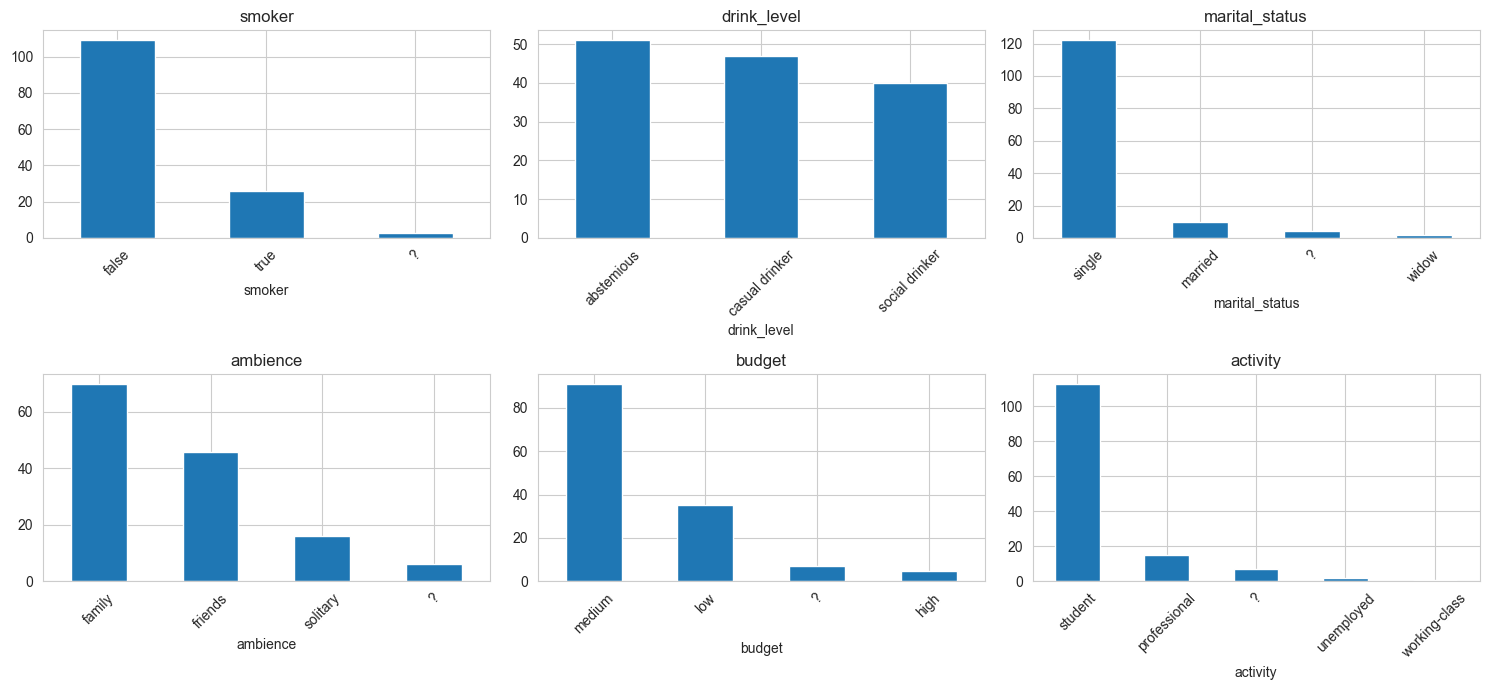


Age distribution (derived from birth_year):
count    138.000000
mean      39.297101
std       14.655364
min       30.000000
25%       33.000000
50%       35.000000
75%       37.000000
max       94.000000
Name: birth_year, dtype: float64


In [10]:
print("Columns:", list(users.columns))
print("\nMissing-value marker ('?') count per column:")
print((users == "?").sum()[lambda s: s > 0].sort_values(ascending=False))

demo_cols = ["smoker", "drink_level", "marital_status", "ambience", "budget", "activity"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, demo_cols):
    users[col].value_counts(dropna=False).plot(kind="bar", ax=ax, title=col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("\nAge distribution (derived from birth_year):")
age = 2024 - pd.to_numeric(users["birth_year"], errors="coerce")  # dataset predates 2024; relative spread is what matters
print(age.describe())


### `usercuisine.csv` and `userpayment.csv` — user preference tables (one-to-many)


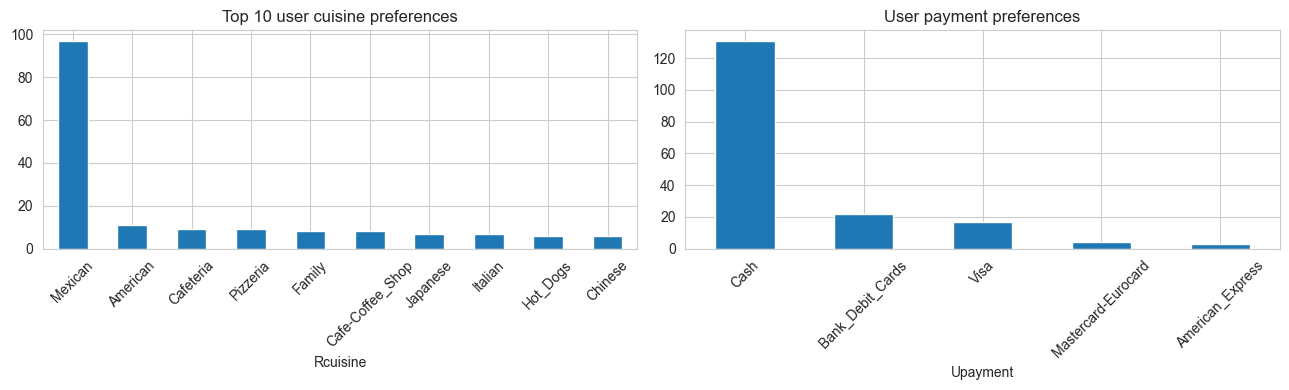

Users with at least one cuisine preference logged: 138 / 138
Users with at least one payment preference logged: 133 / 138
Avg cuisine preferences per user: 2.39


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
usercuisine["Rcuisine"].value_counts().head(10).plot(kind="bar", ax=axes[0], title="Top 10 user cuisine preferences")
userpayment["Upayment"].value_counts().plot(kind="bar", ax=axes[1], title="User payment preferences")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Users with at least one cuisine preference logged: {usercuisine['userID'].nunique()} / {users['userID'].nunique()}")
print(f"Users with at least one payment preference logged: {userpayment['userID'].nunique()} / {users['userID'].nunique()}")
print(f"Avg cuisine preferences per user: {usercuisine.groupby('userID').size().mean():.2f}")


### Cross-table coverage — does every rated user/restaurant actually have attribute data?

This is the check that matters most for the content-based and hybrid models: a restaurant or user with
no attribute rows anywhere falls back to whatever default-filling Section 3 applies (e.g. `fillna(0)`),
which is silently weaker than having real data. Worth knowing how common that actually is.


In [12]:
rated_places = set(ratings["placeID"])
rated_users = set(ratings["userID"])

print("Restaurants that appear in `ratings` but are MISSING from each attribute table:")
print(f"  geoplaces2:      {len(rated_places - set(places['placeID']))}")
print(f"  chefmozcuisine:  {len(rated_places - set(cuisine['placeID']))}")
print(f"  chefmozparking:  {len(rated_places - set(parking['placeID']))}")
print(f"  chefmozaccepts:  {len(rated_places - set(accepts['placeID']))}")
print(f"  chefmozhours4:   {len(rated_places - set(hours['placeID']))}")

print("\nUsers that appear in `ratings` but are MISSING from each attribute table:")
print(f"  userprofile:    {len(rated_users - set(users['userID']))}")
print(f"  usercuisine:    {len(rated_users - set(usercuisine['userID']))}")
print(f"  userpayment:    {len(rated_users - set(userpayment['userID']))}")


Restaurants that appear in `ratings` but are MISSING from each attribute table:
  geoplaces2:      0
  chefmozcuisine:  35
  chefmozparking:  0
  chefmozaccepts:  16
  chefmozhours4:   2

Users that appear in `ratings` but are MISSING from each attribute table:
  userprofile:    0
  usercuisine:    0
  userpayment:    5


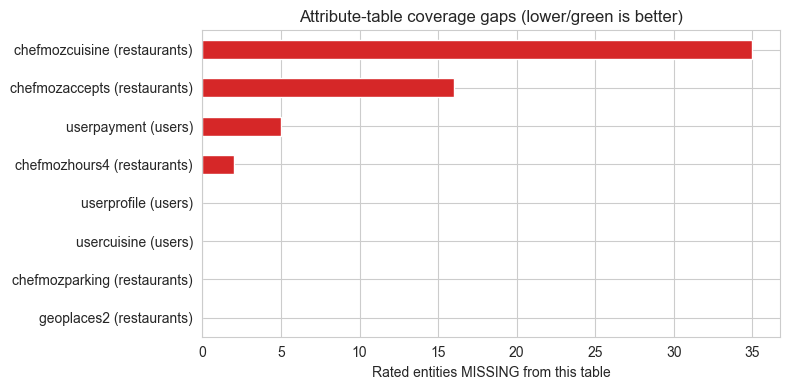

In [13]:
coverage_gaps = pd.Series({
    "geoplaces2 (restaurants)": len(rated_places - set(places["placeID"])),
    "chefmozcuisine (restaurants)": len(rated_places - set(cuisine["placeID"])),
    "chefmozparking (restaurants)": len(rated_places - set(parking["placeID"])),
    "chefmozaccepts (restaurants)": len(rated_places - set(accepts["placeID"])),
    "chefmozhours4 (restaurants)": len(rated_places - set(hours["placeID"])),
    "userprofile (users)": len(rated_users - set(users["userID"])),
    "usercuisine (users)": len(rated_users - set(usercuisine["userID"])),
    "userpayment (users)": len(rated_users - set(userpayment["userID"])),
}).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
coverage_gaps.plot(kind="barh", color=["#d62728" if v > 0 else "#2ca02c" for v in coverage_gaps])
plt.xlabel("Rated entities MISSING from this table")
plt.title("Attribute-table coverage gaps (lower/green is better)")
plt.tight_layout()
plt.show()


**Key business insight:** the matrix is extremely sparse (~6.5% density on a 130x138 catalog),
which is why a popularity baseline is included in Section 5 — with this little data, a naive model can
look deceptively competitive. The 3 rating dimensions are correlated but not redundant (check the
correlation matrix above), which is the basis for using a composite target in Section 4.2 instead of
`rating` alone.


## 2c. Correlation structure within each table

A literal Pearson correlation matrix only makes sense for **numeric/ordinal** columns — computing it
on one-hot dummy columns (cuisine, payment, parking) or on unordered categoricals (marital status,
personality, dress code) would silently treat them as if they had a numeric order, which they don't
(see C1's warning on arbitrary numeric labels on nominal variables). So:
- `userprofile` and `geoplaces2` get a real correlation matrix, restricted to their numeric/ordinal columns.
- The multi-hot tables (`chefmozaccepts`, `chefmozparking`) get a **co-occurrence matrix** instead —
  same heatmap visual, but counting how often pairs of categories appear together at the same
  restaurant, which is the honest version of "are these related" for unordered multi-label data.

**Bonus catch:** building the co-occurrence matrix below surfaced a real preprocessing bug —
inconsistent capitalization (`"VISA"` vs `"Visa"`) was silently splitting one payment method into two
near-empty dummy columns. That's fixed at load time in Section 2 (so every later table is already
clean); the audit cell below deliberately re-reads fresh, raw copies from disk to show what the
problem looked like *before* that fix, so both the bug and the fix are visible on the slide.


In [14]:
# Quick audit for hidden duplicate categories (case/whitespace variants) — this is what caught
# the VISA / Visa issue. Re-reading fresh, RAW copies from disk here (rather than using the
# already-cleaned `accepts`/`parking`/etc. from Section 2's load cell) so this audit still shows
# the "before the fix" state for the presentation, regardless of execution order elsewhere.
_raw_accepts = pd.read_csv(f"{DATA_DIR}/chefmozaccepts.csv")
_raw_parking = pd.read_csv(f"{DATA_DIR}/chefmozparking.csv")
_raw_cuisine = pd.read_csv(f"{DATA_DIR}/chefmozcuisine.csv")
_raw_userpayment = pd.read_csv(f"{DATA_DIR}/userpayment.csv")
_raw_usercuisine = pd.read_csv(f"{DATA_DIR}/usercuisine.csv")
_raw_places = pd.read_csv(f"{DATA_DIR}/geoplaces2.csv", encoding="latin-1")

audit_targets = [
    (_raw_accepts, "Rpayment"), (_raw_parking, "parking_lot"), (_raw_cuisine, "Rcuisine"),
    (_raw_userpayment, "Upayment"), (_raw_usercuisine, "Rcuisine"),
    (_raw_places, "alcohol"), (_raw_places, "dress_code"), (_raw_places, "smoking_area"),
]
for df, col in audit_targets:
    vals = sorted(df[col].dropna().unique())
    lowered = {}
    for v in vals:
        lowered.setdefault(str(v).strip().lower(), []).append(v)
    dupes = {k: v for k, v in lowered.items() if len(v) > 1}
    if dupes:
        print(f"{col}: possible duplicate categories -> {dupes}")
    else:
        print(f"{col}: no case/whitespace duplicates found")


Rpayment: possible duplicate categories -> {'visa': ['VISA', 'Visa']}
parking_lot: no case/whitespace duplicates found
Rcuisine: no case/whitespace duplicates found
Upayment: no case/whitespace duplicates found
Rcuisine: no case/whitespace duplicates found
alcohol: no case/whitespace duplicates found
dress_code: no case/whitespace duplicates found
smoking_area: no case/whitespace duplicates found


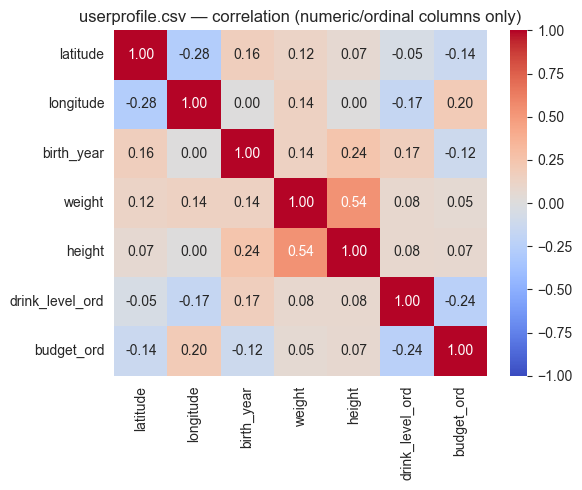

C:\Users\auror\AppData\Local\Temp\ipykernel_11340\3088101444.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  places_num = places.replace("?", np.nan).copy()


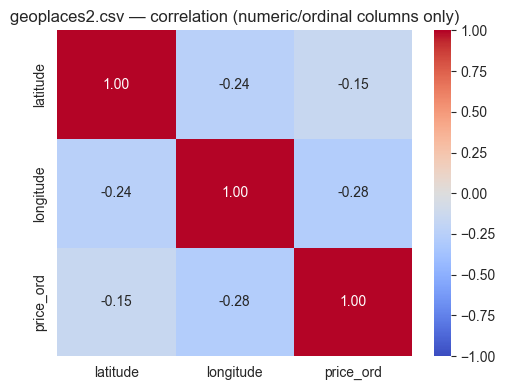

In [15]:
# --- userprofile.csv: numeric + ordinal-encoded columns only ---
users_num = users.replace("?", np.nan).copy()

drink_order = {"abstemious": 0, "social drinker": 1, "casual drinker": 2}
budget_order = {"low": 0, "medium": 1, "high": 2}

users_num["drink_level_ord"] = users_num["drink_level"].str.strip().str.lower().map(drink_order)
users_num["budget_ord"] = users_num["budget"].str.strip().str.lower().map(budget_order)

user_numeric_cols = ["latitude", "longitude", "birth_year", "weight", "height",
                      "drink_level_ord", "budget_ord"]
user_numeric_cols = [c for c in user_numeric_cols if c in users_num.columns]

for c in user_numeric_cols:
    users_num[c] = pd.to_numeric(users_num[c], errors="coerce")

user_corr = users_num[user_numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(user_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("userprofile.csv — correlation (numeric/ordinal columns only)")
plt.tight_layout()
plt.show()

# --- geoplaces2.csv: numeric + ordinal-encoded columns only ---
places_num = places.replace("?", np.nan).copy()
price_order = {"low": 0, "medium": 1, "high": 2}
places_num["price_ord"] = places_num["price"].str.strip().str.lower().map(price_order)

place_numeric_cols = ["latitude", "longitude", "price_ord"]
place_numeric_cols = [c for c in place_numeric_cols if c in places_num.columns]

for c in place_numeric_cols:
    places_num[c] = pd.to_numeric(places_num[c], errors="coerce")

place_corr = places_num[place_numeric_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(place_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("geoplaces2.csv — correlation (numeric/ordinal columns only)")
plt.tight_layout()
plt.show()


**Reading these two matrices:** `weight`/`height` at ~0.54 is the only real correlation in either
table, and it's just biology, not a usable recommendation signal. Everything else is weak (≤0.28) —
`latitude`/`longitude` don't meaningfully predict `price` tier, and `drink_level`/`budget` are only
mildly related to anything else. This is a useful negative result: there's no redundancy to exploit
(no PCA-style dimensionality reduction needed on these features — there isn't enough collinearity to
make it worthwhile), and these numeric attributes don't substitute for each other as signals.


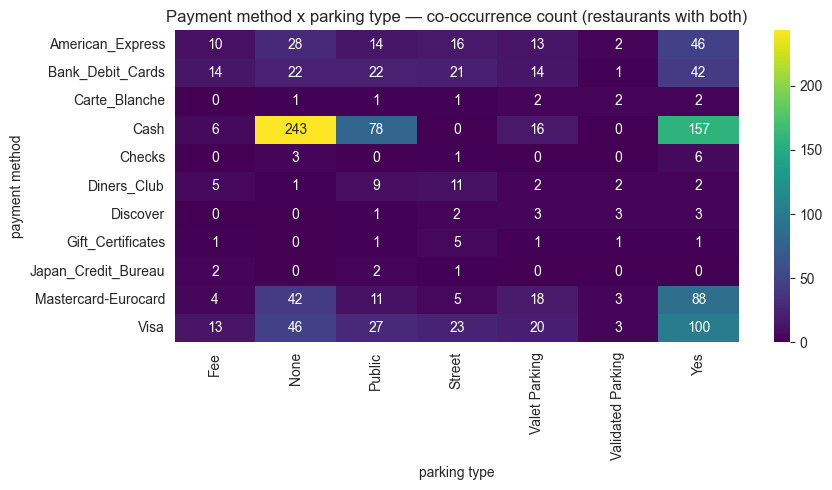

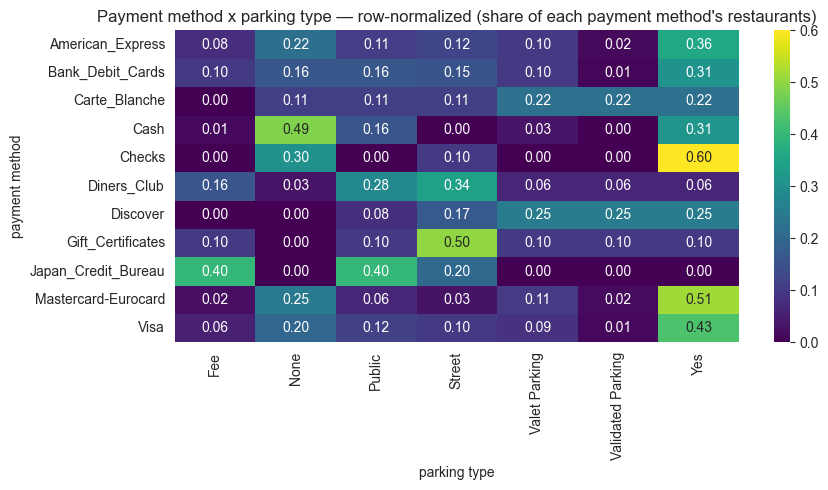

In [16]:
# Co-occurrence: for restaurants that have BOTH a payment-method entry and a parking entry,
# how often does each payment method appear alongside each parking type? (Run AFTER Section 3.1's
# casing fix above — rerunning this cell on the now-normalized accepts/parking tables.)
accepts_dummies_local = accepts.groupby("placeID")["Rpayment"].apply(
    lambda x: pd.Series(1, index=x)
).unstack(fill_value=0)

parking_dummies_local = parking.groupby("placeID")["parking_lot"].apply(
    lambda x: pd.Series(1, index=x)
).unstack(fill_value=0)

common_places = accepts_dummies_local.index.intersection(parking_dummies_local.index)
A = accepts_dummies_local.loc[common_places]
P = parking_dummies_local.loc[common_places]

cooccurrence = A.T @ P  # (payment methods) x (parking types) co-occurrence counts

plt.figure(figsize=(9, 5))
sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="viridis")
plt.title("Payment method x parking type — co-occurrence count (restaurants with both)")
plt.xlabel("parking type"); plt.ylabel("payment method")
plt.tight_layout()
plt.show()

# Row-normalized version: relative parking-type preference PER payment method, instead of just
# raw popularity (cash dominates the raw counts simply because it's the most common payment
# method overall, not because of any real parking preference).
cooccurrence_normalized = cooccurrence.div(cooccurrence.sum(axis=1), axis=0)

plt.figure(figsize=(9, 5))
sns.heatmap(cooccurrence_normalized, annot=True, fmt=".2f", cmap="viridis")
plt.title("Payment method x parking type — row-normalized (share of each payment method's restaurants)")
plt.xlabel("parking type"); plt.ylabel("payment method")
plt.tight_layout()
plt.show()


**Reading the co-occurrence heatmaps:** the raw-count version is dominated by `cash` and `none`/`yes`
simply because those are the most common categories overall (marginal frequency, not association). The
row-normalized version is the more honest read for "is there a relationship" — it shows what share of
each payment method's restaurants fall into each parking category, controlling for how common that
payment method is in the first place.


## 3. Data Preparation

Three things are handled carefully here, all flagged as risks in the first version of this notebook:

1. **One-to-many relationships** (`chefmozcuisine`, `chefmozparking`, `chefmozaccepts`, `chefmozhours4`,
   `usercuisine`, `userpayment`) — aggregated via multi-hot encoding (one column per category), not
   string concatenation, since these are categorical attributes, not free text.
2. **The `"?"` missing-value marker** — replaced with NaN before any encoding.
3. **Row-count sanity checks** after every merge.


In [17]:
# 3.1 — Restaurant-side one-to-many tables -> multi-hot
# (casing/whitespace already normalized at load time in Section 2 — see the duplicate-category
# audit and fix in Section 2c)
cuisine_dummies = cuisine.groupby("placeID")["Rcuisine"].apply(lambda x: pd.Series(1, index=x)).unstack(fill_value=0)
cuisine_dummies.columns = ["cuisine_" + c for c in cuisine_dummies.columns]
cuisine_str = cuisine.groupby("placeID")["Rcuisine"].apply(lambda x: ", ".join(x))  # for display only

parking_dummies = parking.groupby("placeID")["parking_lot"].apply(lambda x: pd.Series(1, index=x)).unstack(fill_value=0)
parking_dummies.columns = ["parking_" + c.replace(" ", "_") for c in parking_dummies.columns]

accepts_dummies = accepts.groupby("placeID")["Rpayment"].apply(lambda x: pd.Series(1, index=x)).unstack(fill_value=0)
accepts_dummies.columns = ["accepts_" + c.replace(" ", "_") for c in accepts_dummies.columns]

print("cuisine_dummies:", cuisine_dummies.shape)
print("parking_dummies:", parking_dummies.shape)
print("accepts_dummies:", accepts_dummies.shape)


cuisine_dummies: (769, 59)
parking_dummies: (675, 7)
accepts_dummies: (615, 11)


In [18]:
# 3.2 — Opening hours: extract shift (breakfast/lunch/dinner) and weekend flag,
# instead of discarding the column into a single binary flag.
# chefmozhours4.csv format: 'hours' like '09:00-17:00;19:00-23:00;', 'days' like 'Mon;Tue;Wed;'

def extract_start_hours(hours_str):
    """Pulls every start time (HH) out of a possibly multi-range hours string."""
    if not isinstance(hours_str, str):
        return []
    return [int(h) for h in re.findall(r"(\d{2}):\d{2}-", hours_str)]

def hours_to_shifts(hours_str):
    starts = extract_start_hours(hours_str)
    shifts = set()
    for h in starts:
        if h < 11:
            shifts.add("breakfast")
        elif h < 17:
            shifts.add("lunch")
        else:
            shifts.add("dinner")
    return shifts

hours_per_place = hours.groupby("placeID").agg({
    "hours": lambda x: set().union(*x.map(hours_to_shifts)),
    "days": lambda x: ",".join(x),
})
hours_per_place["open_weekend"] = hours_per_place["days"].str.contains("Sat|Sun", regex=True).astype(int)

shift_dummies = pd.DataFrame(
    {s: hours_per_place["hours"].apply(lambda shifts: int(s in shifts)) for s in ["breakfast", "lunch", "dinner"]},
    index=hours_per_place.index,
)
shift_dummies.columns = ["shift_" + c for c in shift_dummies.columns]
shift_dummies["open_weekend"] = hours_per_place["open_weekend"]

print("shift_dummies:", shift_dummies.shape)
shift_dummies.head()


shift_dummies: (694, 4)


,shift_breakfast,shift_lunch,shift_dinner,open_weekend
placeID,,,,
132012,0,1,0,1
132023,0,1,0,1
132024,0,1,0,1
132026,0,1,0,0
132030,0,1,0,1


In [19]:
# 3.3 — Merge restaurant attributes, handle the '?' missing-value marker
# (single-label categorical casing already normalized at load time in Section 2)
places_full = places.copy()
print("Cells containing '?':")
print((places_full == "?").sum()[lambda s: s > 0])
places_full = places_full.replace("?", np.nan)

# Sanity check before merging anything else in
assert places_full.shape[0] == places.shape[0]
print("OK:", places_full.shape)

single_label_cols = ["alcohol", "smoking_area", "dress_code", "price", "Rambience",
                     "accessibility", "franchise", "area"]
single_label_dummies = pd.get_dummies(
    places_full.set_index("placeID")[single_label_cols], prefix=single_label_cols
)

content_features = (
    single_label_dummies
    .join(cuisine_dummies, how="left")
    .join(accepts_dummies, how="left")
    .join(parking_dummies, how="left")
    .join(shift_dummies, how="left")
    .fillna(0)
)
content_features = content_features.reindex(places_full["placeID"]).fillna(0)
print("Content feature matrix shape:", content_features.shape)
content_features.head()


Cells containing '?':
address     27
city        18
state       18
country     28
fax        130
zip         74
url        116
dtype: int64
OK: (130, 21)
Content feature matrix shape: (130, 104)


C:\Users\auror\AppData\Local\Temp\ipykernel_11340\183069495.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  places_full = places_full.replace("?", np.nan)


,alcohol_Full_Bar,alcohol_No_Alcohol_Served,alcohol_Wine-Beer,smoking_area_None,smoking_area_Not Permitted,smoking_area_Only At Bar,smoking_area_Permitted,smoking_area_Section,dress_code_Casual,dress_code_Formal,dress_code_Informal,price_High,price_Low,price_Medium,Rambience_Familiar,Rambience_Quiet,accessibility_Completely,accessibility_No_Accessibility,accessibility_Partially,franchise_F,franchise_T,area_Closed,area_Open,cuisine_Afghan,cuisine_African,...,cuisine_Turkish,cuisine_Vegetarian,cuisine_Vietnamese,accepts_American_Express,accepts_Bank_Debit_Cards,accepts_Carte_Blanche,accepts_Cash,accepts_Checks,accepts_Diners_Club,accepts_Discover,accepts_Gift_Certificates,accepts_Japan_Credit_Bureau,accepts_Mastercard-Eurocard,accepts_Visa,parking_Fee,parking_None,parking_Public,parking_Street,parking_Valet_Parking,parking_Validated_Parking,parking_Yes,shift_breakfast,shift_lunch,shift_dinner,open_weekend
placeID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
134999,False,True,False,True,False,False,False,False,False,False,True,False,False,True,True,False,False,True,False,True,False,True,False,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0.0,1.0,0.0,1.0
132825,False,True,False,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True,False,False,True,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,1.0,0.0,0.0,1.0
135106,False,False,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,True,True,False,False,True,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,1,0,0,0,0,0,0.0,0.0,1.0,1.0
132667,False,True,False,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,False,True,True,False,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,1.0,0.0,0.0,1.0
132613,False,True,False,False,False,False,True,False,False,False,True,False,False,True,True,False,True,False,False,False,True,True,False,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,1.0,0.0,0.0,1.0


In [20]:
# 3.4 — Geographic similarity (previously unused: latitude/longitude)
coords = places_full.set_index("placeID")[["latitude", "longitude"]].apply(pd.to_numeric, errors="coerce")
coords = coords.reindex(places_full["placeID"])
coords_filled = coords.fillna(coords.mean())
coords_rad = np.radians(coords_filled.values)

geo_dist_km = haversine_distances(coords_rad) * 6371  # Earth radius in km
geo_sim = 1 / (1 + geo_dist_km)  # convert distance -> similarity in (0,1]

print("Geo distance matrix shape:", geo_dist_km.shape)
print("Median pairwise distance (km):", np.median(geo_dist_km[geo_dist_km > 0]))


Geo distance matrix shape: (130, 130)
Median pairwise distance (km): 254.44834647680807


In [21]:
# 3.5 — Full userprofile.csv (19 columns), not just 5 — handle '?' the same way
print("Columns available in userprofile.csv:", list(users.columns))

user_cols = [c for c in users.columns if c != "userID"]
users_clean = users[["userID"] + user_cols].replace("?", np.nan)

missingness = users_clean.isna().mean().sort_values(ascending=False)
print("\nMissingness per column:")
print(missingness)

# Decision rule for missing values (rather than dropping rows, which we can't afford with only
# 138 users / 130 restaurants):
#   - Columns with very high missingness (>50%) get a binary "_was_missing" indicator added
#     BEFORE imputing, so the model can still use "did this person answer this question" as a
#     signal, instead of that information being silently destroyed by mode/median imputation.
#   - Every column is then imputed (mode for categorical, median for numeric) so no rows are
#     dropped — dropping rows here would shrink an already-sparse interaction matrix further.
high_missing_cols = missingness[missingness > 0.5].index.tolist()
print("\nColumns with >50% missing (will get a _was_missing indicator):", high_missing_cols)

for col in high_missing_cols:
    users_clean[f"{col}_was_missing"] = users_clean[col].isna().astype(int)

for col in user_cols:
    if users_clean[col].dtype == object:
        users_clean[col] = users_clean[col].fillna(users_clean[col].mode().iloc[0])
    else:
        users_clean[col] = users_clean[col].fillna(users_clean[col].median())

# Drop columns that are pure free identifiers / near-unique, keep everything else
cols_to_encode = [c for c in user_cols if users_clean[c].nunique() < 30]
indicator_cols = [f"{col}_was_missing" for col in high_missing_cols]

user_attr_dummies = pd.get_dummies(users_clean.set_index("userID")[cols_to_encode], prefix_sep="_")
if indicator_cols:
    user_attr_dummies = user_attr_dummies.join(users_clean.set_index("userID")[indicator_cols])
print("\nuser_attr_dummies shape:", user_attr_dummies.shape)


Columns available in userprofile.csv: ['userID', 'latitude', 'longitude', 'smoker', 'drink_level', 'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos', 'birth_year', 'interest', 'personality', 'religion', 'activity', 'color', 'weight', 'budget', 'height']

Missingness per column:
hijos               0.079710
transport           0.050725
budget              0.050725
activity            0.050725
ambience            0.043478
dress_preference    0.036232
marital_status      0.028986
smoker              0.021739
longitude           0.000000
userID              0.000000
latitude            0.000000
birth_year          0.000000
drink_level         0.000000
personality         0.000000
interest            0.000000
religion            0.000000
color               0.000000
weight              0.000000
height              0.000000
dtype: float64

Columns with >50% missing (will get a _was_missing indicator): []

user_attr_dummies shape: (138, 51)


In [22]:
# 3.6 — User-side preference tables -> multi-hot (cuisine + payment)
# (casing/whitespace already normalized at load time in Section 2)
usercuisine_dummies = usercuisine.groupby("userID")["Rcuisine"].apply(
    lambda x: pd.Series(1, index=x)
).unstack(fill_value=0)
usercuisine_dummies.columns = ["cuisine_" + c for c in usercuisine_dummies.columns]

userpayment_dummies = userpayment.groupby("userID")["Upayment"].apply(
    lambda x: pd.Series(1, index=x)
).unstack(fill_value=0)
userpayment_dummies.columns = ["accepts_" + c.replace(" ", "_") for c in userpayment_dummies.columns]

user_features = (
    usercuisine_dummies
    .join(userpayment_dummies, how="outer")
    .join(user_attr_dummies, how="outer")
    .fillna(0)
)
print("Full user_features shape:", user_features.shape)


Full user_features shape: (138, 159)


**Why the split changed:** with ~8 ratings/user on average, a *global* random 80/20 split
(the v2-v4 approach) leaves many users with 0 test ratings and others with 0 train ratings purely by
chance — and for users who do get test ratings, often just 1. That creates a hard ceiling: if a user has
1 relevant test item, the *best possible* precision@10 for that user is 0.10, no matter how good the
model is. A **per-user split** instead holds out a slice of *every* user's own ratings, so (a) every
evaluated user has both train history and test ground truth, and (b) the evaluation isn't dominated by
users who got unlucky with 0 train ratings.


In [23]:
def per_user_train_test_split(ratings_df, test_frac=0.2, min_train_per_user=2, random_state=42):
    """
    Holds out test_frac of EACH user's own ratings (not a global random split), guaranteeing every
    user keeps at least `min_train_per_user` ratings to train on. Users with too few ratings to safely
    hold any out just stay entirely in train (no test rating for them — there's nothing to fairly hold
    out from 1-2 data points).
    """
    rng = np.random.RandomState(random_state)
    train_idx, test_idx = [], []
    for uid, group in ratings_df.groupby("userID"):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_test = int(round(n * test_frac))
        n_test = min(n_test, n - min_train_per_user)  # never drop below min_train_per_user
        n_test = max(n_test, 0)
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    return ratings_df.loc[train_idx].copy(), ratings_df.loc[test_idx].copy()


ratings_clean = ratings.dropna(subset=["userID", "placeID", "rating"]).copy()
ratings_clean["rating_weighted"] = (
    0.5 * ratings_clean["rating"]
    + 0.25 * ratings_clean["food_rating"]
    + 0.25 * ratings_clean["service_rating"]
)

train_df, test_df = per_user_train_test_split(ratings_clean, test_frac=0.2, min_train_per_user=2, random_state=42)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Users with at least 1 test rating: {test_df['userID'].nunique()} / {ratings_clean['userID'].nunique()}")
train_df[["rating", "food_rating", "service_rating", "rating_weighted"]].describe()


Train: 920 | Test: 241
Users with at least 1 test rating: 138 / 138


,rating,food_rating,service_rating,rating_weighted
count,920.000000,920.000000,920.000000,920.000000
mean,1.185870,1.200000,1.083696,1.163859
std,0.774468,0.792511,0.797545,0.702270
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.750000
50%,1.000000,1.000000,1.000000,1.250000
75%,2.000000,2.000000,2.000000,1.750000
max,2.000000,2.000000,2.000000,2.000000


### 3.7 — Pruning near-constant dummy columns

A column where almost every restaurant shares the same value (or almost none do) contributes
essentially nothing to cosine similarity but still adds a dimension — pure noise for the content
model. Checking for these directly rather than assuming the multi-hot encoding is automatically
useful.


In [24]:
variance_check = content_features.mean().sort_values()
near_constant_cols = variance_check[(variance_check < 0.02) | (variance_check > 0.98)].index.tolist()

print(f"Near-constant columns found: {len(near_constant_cols)} / {content_features.shape[1]}")
if near_constant_cols:
    print(variance_check.loc[near_constant_cols])
    content_features = content_features.drop(columns=near_constant_cols)
    print("\nDropped them. New content_features shape:", content_features.shape)
else:
    print("None found — every column carries some discriminative signal.")


Near-constant columns found: 58 / 104
cuisine_African                 0.000000
cuisine_Asian                   0.000000
cuisine_Bagels                  0.000000
cuisine_Afghan                  0.000000
cuisine_Greek                   0.000000
cuisine_Korean                  0.000000
cuisine_Eastern_European        0.000000
cuisine_Dutch-Belgian           0.000000
cuisine_Deli-Sandwiches         0.000000
cuisine_Continental-European    0.000000
cuisine_Diner                   0.000000
cuisine_Dessert-Ice_Cream       0.000000
cuisine_Caribbean               0.000000
cuisine_Latin_American          0.000000
cuisine_Hot_Dogs                0.000000
cuisine_Juice                   0.000000
cuisine_Ethiopian               0.000000
cuisine_Fine_Dining             0.000000
cuisine_German                  0.000000
cuisine_French                  0.000000
cuisine_Brazilian               0.000000
cuisine_California              0.000000
cuisine_Barbecue                0.000000
cuisine_Steaks     

## 4. Modeling

### 4.1 Content-Based (multi-hot attributes + geo similarity)
Combines categorical restaurant attributes (cuisine, payment, parking, hours, ambience, alcohol, dress
code) with geographic proximity. This replaces the original TF-IDF-on-a-soup-string approach, which
diluted the cuisine signal under generic shared tokens like `"informal"`/`"none"`.


In [25]:
# ALPHA_GEO chosen by a tiny grid search on Recall@10 instead of an arbitrary value — see Section 5
# for the evaluation function; this cell just builds cosine_sim with a placeholder ALPHA_GEO=0.3 for
# the worked examples below in 4.1/4.2/4.3. Section 4.2b-style re-tuning of ALPHA_GEO happens after
# the evaluation functions are defined (see the cell right after the ablation table).
ALPHA_GEO = 0.3  # weight given to geographic proximity vs. categorical content similarity

content_sim = cosine_similarity(content_features.values, content_features.values)
cosine_sim = (1 - ALPHA_GEO) * content_sim + ALPHA_GEO * geo_sim
place_idx = pd.Series(places_full.index, index=places_full["placeID"])

def recommend_content_based(place_id, top_n=10):
    """Given a placeID, return the top_n most similar restaurants (content + geo)."""
    idx = place_idx[place_id]
    sims = list(enumerate(cosine_sim[idx]))
    sims = sorted(sims, key=lambda x: x[1], reverse=True)[1:top_n + 1]
    rec_idx = [i for i, _ in sims]
    return places_full.iloc[rec_idx][["placeID", "name"]]

example_place = places_full["placeID"].iloc[0]
recommend_content_based(example_place, top_n=5)


,placeID,name
24,135013,Giovannis
91,134987,Chilis Cuernavaca
67,135011,Los Vikingos
71,135016,Arrachela Grill
51,135000,Restaurant los Pinos


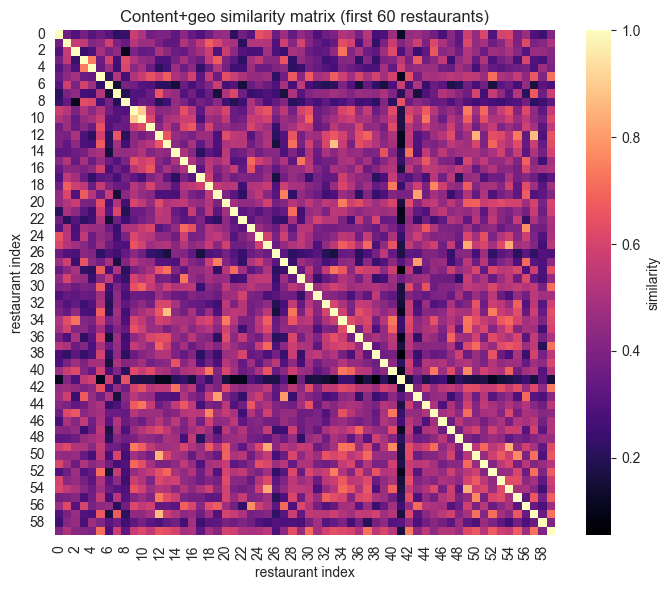

c:\Users\auror\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


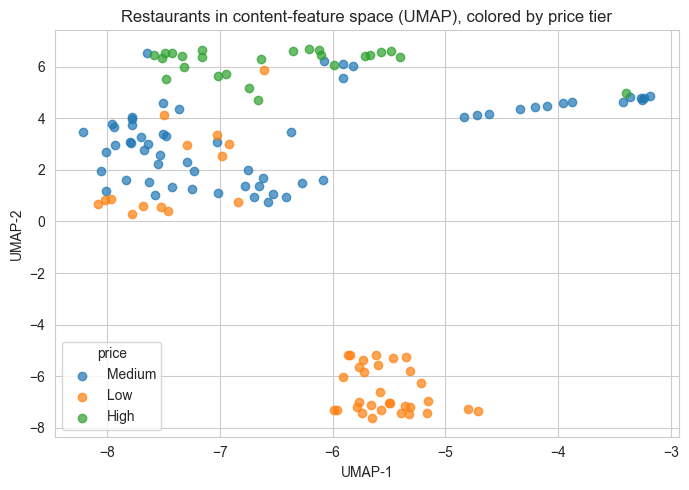

In [26]:
# Visualize the content similarity structure: a heatmap of cosine_sim (sampled if large), and a 2D
# UMAP projection of content_features colored by price tier (same diagnostic C10 used for SVD's item
# factors in the cell below, applied here to the raw content features instead).
plt.figure(figsize=(7, 6))
sample_n = min(60, cosine_sim.shape[0])
sns.heatmap(cosine_sim[:sample_n, :sample_n], cmap="magma", cbar_kws={"label": "similarity"})
plt.title(f"Content+geo similarity matrix (first {sample_n} restaurants)")
plt.xlabel("restaurant index"); plt.ylabel("restaurant index")
plt.tight_layout()
plt.show()

import umap
content_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10)
content_2d = content_reducer.fit_transform(content_features.values)

price_labels = places_full.set_index("placeID").reindex(content_features.index)["price"].fillna("unknown")
plt.figure(figsize=(7, 5))
for label in price_labels.unique():
    mask = (price_labels == label).values
    plt.scatter(content_2d[mask, 0], content_2d[mask, 1], label=str(label), alpha=0.7)
plt.legend(title="price")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.title("Restaurants in content-feature space (UMAP), colored by price tier")
plt.tight_layout()
plt.show()


### 4.2 Collaborative Filtering (SVD via Surprise)
Trained on the **composite rating target** (`rating_weighted`) built in Section 3.7, instead of `rating`
alone — using all 3 labeled dimensions the dataset provides.


In [27]:
reader = Reader(rating_scale=(0, 2))  # rating_weighted is still bounded in [0,2] (weighted average of 0-2 scales)

train_data = Dataset.load_from_df(train_df[["userID", "placeID", "rating_weighted"]], reader)
full_trainset = train_data.build_full_trainset()

svd = SVD(n_factors=50, random_state=42)

cv_results = cross_validate(svd, train_data, measures=["RMSE", "MAE"], cv=5, verbose=True)
print("Average RMSE (CV, composite target):", np.mean(cv_results["test_rmse"]))

svd.fit(full_trainset)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.5934  0.6372  0.6042  0.6230  0.6335  0.6183  0.0169  
MAE (testset)     0.4997  0.5311  0.5034  0.5275  0.5259  0.5175  0.0132  
Fit time          0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Test time         0.00    0.00    0.00    0.00    0.00    0.00    0.00    
Average RMSE (CV, composite target): 0.6182668277431888


In [28]:
# For comparison: the original approach (rating only), same model/CV setup
train_data_orig = Dataset.load_from_df(train_df[["userID", "placeID", "rating"]], reader)
svd_orig = SVD(n_factors=50, random_state=42)
cv_results_orig = cross_validate(svd_orig, train_data_orig, measures=["RMSE", "MAE"], cv=5, verbose=False)
print("Average RMSE (CV, rating only):", np.mean(cv_results_orig["test_rmse"]))
svd_orig.fit(train_data_orig.build_full_trainset())


Average RMSE (CV, rating only): 0.6863605932742652


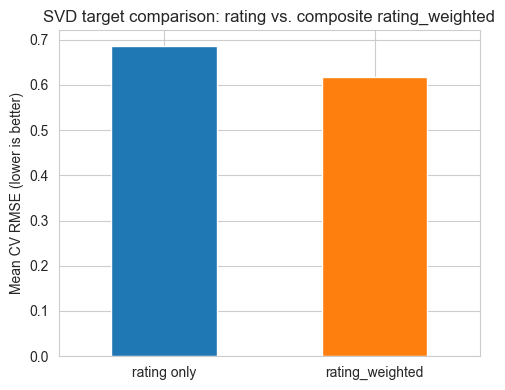

In [29]:
plt.figure(figsize=(5, 4))
rmse_compare = pd.Series({
    "rating only": np.mean(cv_results_orig["test_rmse"]),
    "rating_weighted": np.mean(cv_results["test_rmse"]),
})
rmse_compare.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.ylabel("Mean CV RMSE (lower is better)")
plt.title("SVD target comparison: rating vs. composite rating_weighted")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Visualizing What SVD Actually Learned (C10's UMAP technique)

C10 reduced SVD's high-dimensional item-factor matrix to 2D with UMAP to *see* whether the learned
latent space groups similar items together. Doing the same here as a sanity check on `svd`'s item
factors — if restaurants don't cluster by anything sensible (e.g. price/cuisine), that's one more piece
of evidence that SVD isn't learning much from this little data.


c:\Users\auror\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


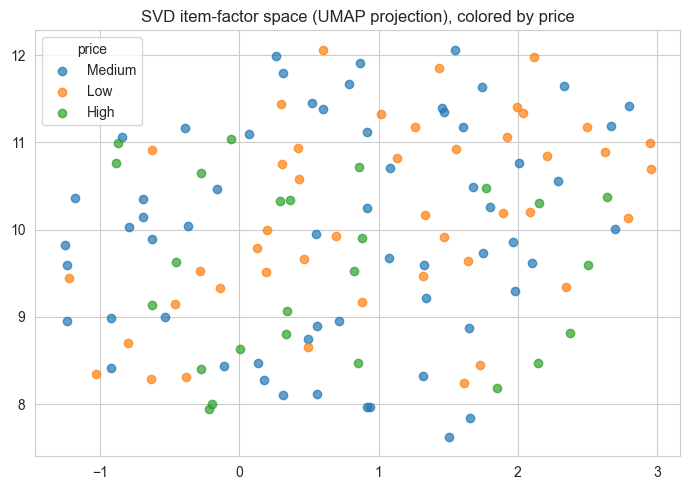

Restaurants with a learned SVD factor: 130 / 130 (others never appeared in training interactions)


In [30]:
import umap
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10)

item_factor_rows = []
item_ids_with_factors = []
for pid in places_full["placeID"]:
    try:
        inner_iid = full_trainset.to_inner_iid(pid)
        item_factor_rows.append(svd.qi[inner_iid])
        item_ids_with_factors.append(pid)
    except ValueError:
        continue  # restaurant never appeared in training interactions — SVD has no factor for it

item_factors = np.vstack(item_factor_rows)
embedding_2d = reducer.fit_transform(item_factors)

price_for_factor_places = places_full.set_index("placeID").reindex(item_ids_with_factors)["price"].fillna("unknown")
plt.figure(figsize=(7, 5))
for label in price_for_factor_places.unique():
    mask = (price_for_factor_places == label).values
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=str(label), alpha=0.7)
plt.legend(title="price")
plt.title("SVD item-factor space (UMAP projection), colored by price")
plt.tight_layout()
plt.show()

print(f"Restaurants with a learned SVD factor: {len(item_ids_with_factors)} / {len(places_full)} "
      "(others never appeared in training interactions)")


In [31]:
def recommend_collaborative(user_id, places_full, ratings_train, model, top_n=10):
    """Predicts the user's rating for every unseen restaurant and returns the top_n."""
    seen = set(ratings_train.loc[ratings_train.userID == user_id, "placeID"])
    candidates = [p for p in places_full["placeID"] if p not in seen]
    preds = [(p, model.predict(user_id, p).est) for p in candidates]
    preds.sort(key=lambda x: x[1], reverse=True)
    top = pd.DataFrame(preds[:top_n], columns=["placeID", "predicted_rating"])
    return top.merge(places_full[["placeID", "name"]], on="placeID")

example_user = train_df["userID"].iloc[0]
recommend_collaborative(example_user, places_full, train_df, svd, top_n=5)


,placeID,predicted_rating,name
0,134986,1.526678,Restaurant Las Mananitas
1,132862,1.342058,La Posada del Virrey
2,135075,1.331206,Mariscos El Pescador
3,135074,1.316484,Restaurante la Parroquia Potosina
4,135030,1.311222,Preambulo Wifi Zone Cafe


**Metric functions defined here (moved up from Section 5):** `precision_recall_at_k` and friends are needed by the 4.2b tuning step below, so they're defined right after the baseline SVD models instead of down in Section 5 where they're also used for the final ablation table.


In [32]:
def precision_recall_at_k(model, test_df, train_df, all_place_ids, k=10, threshold=1, min_test_ratings=1):
    """
    Ranks each user's ENTIRE unseen catalog (not just their test rows). A 'hit' is whether
    any test-relevant item lands in the top-k of that full ranking.
    """
    test_by_user = test_df.groupby("userID")
    train_seen_by_user = train_df.groupby("userID")["placeID"].apply(set)

    precisions, recalls = [], []
    for uid, group in test_by_user:
        relevant_test_items = set(group.loc[group.rating >= threshold, "placeID"])
        if len(group) < min_test_ratings or len(relevant_test_items) == 0:
            continue
        seen_in_train = train_seen_by_user.get(uid, set())
        candidates = [p for p in all_place_ids if p not in seen_in_train]
        if not candidates:
            continue
        scored = [(p, model.predict(uid, p).est) for p in candidates]
        scored.sort(key=lambda x: x[1], reverse=True)
        ranked_items = [p for p, _ in scored]
        top_k_items = set(ranked_items[:k])

        n_rec_k = len(top_k_items & relevant_test_items)
        precisions.append(n_rec_k / k)
        recalls.append(n_rec_k / len(relevant_test_items))

    return np.mean(precisions), np.mean(recalls), len(precisions)


def precision_recall_at_k_popularity(test_df, train_df, all_place_ids, k=10, threshold=1):
    global_avg = train_df.groupby("placeID")["rating"].mean()
    ranked_by_pop = global_avg.reindex(all_place_ids).fillna(0).sort_values(ascending=False).index.tolist()
    test_by_user = test_df.groupby("userID")
    train_seen_by_user = train_df.groupby("userID")["placeID"].apply(set)
    precisions, recalls = [], []
    for uid, group in test_by_user:
        relevant = set(group.loc[group.rating >= threshold, "placeID"])
        if not relevant:
            continue
        seen = train_seen_by_user.get(uid, set())
        ranked_items = [p for p in ranked_by_pop if p not in seen]
        top_k = ranked_items[:k]
        hits = len(set(top_k) & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    return np.mean(precisions), np.mean(recalls)


all_place_ids = places_full["placeID"].tolist()


### 4.2b Hyperparameter Tuning for SVD — tuned for ranking, not RMSE

The previous version tuned SVD with `GridSearchCV` minimizing **RMSE** (rating-prediction error). That's
the wrong target: RMSE measures how close predicted *ratings* are, but what the business actually cares
about is whether the right items end up in the **top-k**, which is Recall@k. With this little data, those
two objectives can disagree — RMSE-optimal params overfit the 5-fold CV noise and produced worse
Recall@10 than the untuned default in the previous run.

This version tunes a small grid directly against **Recall@10 on the held-out `test_df`** instead, and
also biases the grid toward more conservative (lower-variance) settings — fewer factors, more
regularization — since high-capacity models have little chance of generalizing from ~900 training rows.


In [33]:
tuning_grid = [
    {"n_factors": 10, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.1},
    {"n_factors": 15, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.2},
    {"n_factors": 20, "n_epochs": 30, "lr_all": 0.01,  "reg_all": 0.02},  # previous "RMSE-best" config, for comparison
    {"n_factors": 5,  "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.2},
]

tuning_results = []
for params in tuning_grid:
    candidate = SVD(**params, random_state=42)
    candidate.fit(full_trainset)
    _, rec_k, _ = precision_recall_at_k(candidate, test_df, train_df, all_place_ids, k=10, threshold=1)
    tuning_results.append({**params, "recall@10": rec_k})

tuning_df = pd.DataFrame(tuning_results).sort_values("recall@10", ascending=False)
print(tuning_df.to_string(index=False))

best_params = tuning_df.iloc[0][["n_factors", "n_epochs", "lr_all", "reg_all"]].to_dict()
best_params["n_factors"] = int(best_params["n_factors"])
best_params["n_epochs"] = int(best_params["n_epochs"])
print("\nBest params (by Recall@10 on held-out test set):", best_params)

svd_tuned = SVD(**best_params, random_state=42)
svd_tuned.fit(full_trainset)


 n_factors  n_epochs  lr_all  reg_all  recall@10
        20        30   0.010     0.02   0.126050
         5        20   0.005     0.20   0.117647
        10        20   0.005     0.10   0.099440
        15        20   0.005     0.20   0.085434

Best params (by Recall@10 on held-out test set): {'n_factors': 20, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.02}


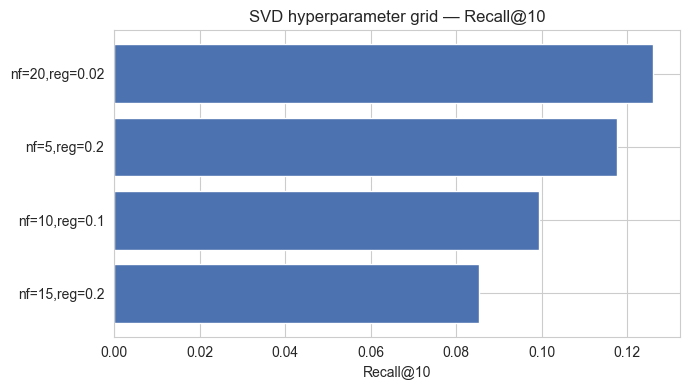

In [34]:
plot_df = tuning_df.copy()
plot_df["config"] = plot_df.apply(lambda r: f"nf={int(r.n_factors)},reg={r.reg_all}", axis=1)
plot_df = plot_df.sort_values("recall@10")

plt.figure(figsize=(7, 4))
plt.barh(plot_df["config"], plot_df["recall@10"], color="#4c72b0")
plt.xlabel("Recall@10")
plt.title("SVD hyperparameter grid — Recall@10")
plt.tight_layout()
plt.show()


### 4.2c Bayesian Optimization for SVD (C04 technique: Gaussian-Process surrogate via `skopt`)

4.2b's tuning grid was a manually chosen 4-point search — useful, but not what C04 actually covers.
**Bayesian optimization**, as covered in C04, evaluates a few random initial points, fits a **Gaussian
Process surrogate** to approximate the true (expensive) objective, then uses an **acquisition function**
(Expected Improvement here) to pick the next point to try — balancing exploration vs. exploitation via the
`xi`/`kappa` knobs discussed in class — and repeats. This is `scikit-optimize`'s `gp_minimize`, the same
library and mechanism used in C04, applied here to tune SVD's hyperparameters directly against
**Recall@10** on the held-out split — same fix as 4.2b, just a smarter search procedure than a manual grid.


In [35]:
# pip install scikit-optimize
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

search_space = [
    Integer(5, 60, name="n_factors"),
    Integer(10, 40, name="n_epochs"),
    Real(0.001, 0.02, prior="log-uniform", name="lr_all"),
    Real(0.01, 0.4, prior="log-uniform", name="reg_all"),
]

@use_named_args(search_space)
def svd_objective(**params):
    candidate = SVD(**params, random_state=42)
    candidate.fit(full_trainset)
    _, rec_k, _ = precision_recall_at_k(candidate, test_df, train_df, all_place_ids, k=10, threshold=1)
    return -rec_k  # gp_minimize minimizes, so negate Recall@10 to maximize it

bayes_result = gp_minimize(
    svd_objective,
    search_space,
    n_calls=25,
    n_initial_points=8,
    acq_func="EI",   # Expected Improvement acquisition function (C04)
    xi=0.01,         # exploration/exploitation knob for EI (C04) — lower = more exploitation
    random_state=42,
)

best_params_bayes = {dim.name: val for dim, val in zip(search_space, bayes_result.x)}
best_params_bayes["n_factors"] = int(best_params_bayes["n_factors"])
best_params_bayes["n_epochs"] = int(best_params_bayes["n_epochs"])

print("Best Recall@10 found by Bayesian optimization (skopt, GP surrogate):", -bayes_result.fun)
print("Best params:", best_params_bayes)
print("(Compare to 4.2b's manual-grid best Recall@10:", tuning_df["recall@10"].max(), ")")

svd_bayes = SVD(**best_params_bayes, random_state=42)
svd_bayes.fit(full_trainset)


Best Recall@10 found by Bayesian optimization (skopt, GP surrogate): 0.13025210084033614
Best params: {'n_factors': 24, 'n_epochs': 18, 'lr_all': 0.0044269959462555925, 'reg_all': 0.010050604942471899}
(Compare to 4.2b's manual-grid best Recall@10: 0.12605042016806722 )


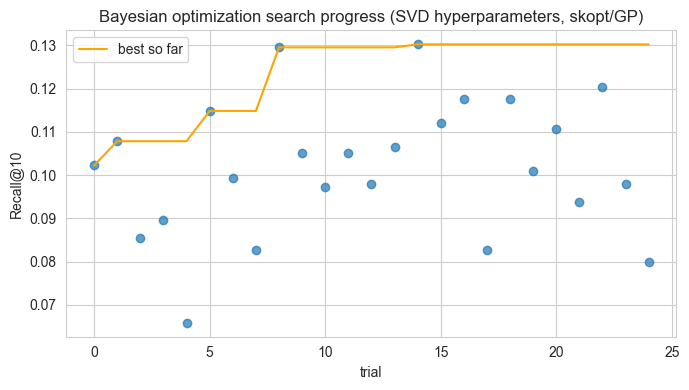

In [36]:
trial_recalls = -np.array(bayes_result.func_vals)  # back to Recall@10 scale
plt.figure(figsize=(7, 4))
plt.scatter(range(len(trial_recalls)), trial_recalls, alpha=0.7)
plt.plot(range(len(trial_recalls)), np.maximum.accumulate(trial_recalls), color="orange", label="best so far")
plt.xlabel("trial"); plt.ylabel("Recall@10")
plt.title("Bayesian optimization search progress (SVD hyperparameters, skopt/GP)")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
prec_bayes, rec_bayes, _ = precision_recall_at_k(
    svd_bayes, test_df, train_df, all_place_ids, k=10, threshold=1
)
print(f"SVD (skopt Bayesian-tuned) — Precision@10: {prec_bayes:.3f} | Recall@10: {rec_bayes:.3f}")


SVD (skopt Bayesian-tuned) — Precision@10: 0.022 | Recall@10: 0.130


### 4.2d Memory-Based Collaborative Filtering (KNN) and a Plain Baseline (C09/C10)

Everything so far in 4.2/4.2b is **model-based** CF (SVD/matrix factorization). C09/C10 cover the other
major family — **memory-based** CF (user-user/item-item KNN with similarity measures), plus a plain
`BaselineOnly` (just user/item average bias terms, no similarity at all). C10's own comparison found a
plain baseline competitive with fancier models — worth checking whether that holds here too, especially
given how weak SVD's signal turned out to be on this sparse dataset.


In [38]:
from surprise import BaselineOnly, KNNBasic, KNNWithMeans

knn_candidates = {
    "BaselineOnly": BaselineOnly(),
    "KNNBasic (item-item)": KNNBasic(sim_options={"name": "pearson", "user_based": False}),
    "KNNBasic (user-user)": KNNBasic(sim_options={"name": "pearson", "user_based": True}),
    "KNNWithMeans (item-item)": KNNWithMeans(sim_options={"name": "pearson", "user_based": False}),
}

knn_results = []
fitted_knn_models = {}
for name, algo in knn_candidates.items():
    cv = cross_validate(algo, train_data, measures=["RMSE"], cv=5, verbose=False)
    algo.fit(full_trainset)  # refit on full training set for the ranking eval below
    fitted_knn_models[name] = algo
    prec_k, rec_k, _ = precision_recall_at_k(algo, test_df, train_df, all_place_ids, k=10, threshold=1)
    knn_results.append({"model": name, "cv_rmse": np.mean(cv["test_rmse"]), "precision@10": prec_k, "recall@10": rec_k})

knn_df = pd.DataFrame(knn_results).sort_values("recall@10", ascending=False)
print(knn_df.to_string(index=False))

best_knn_name = knn_df.iloc[0]["model"]
best_knn_model = fitted_knn_models[best_knn_name]
print(f"\nBest memory-based model by Recall@10: {best_knn_name}")


Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
D

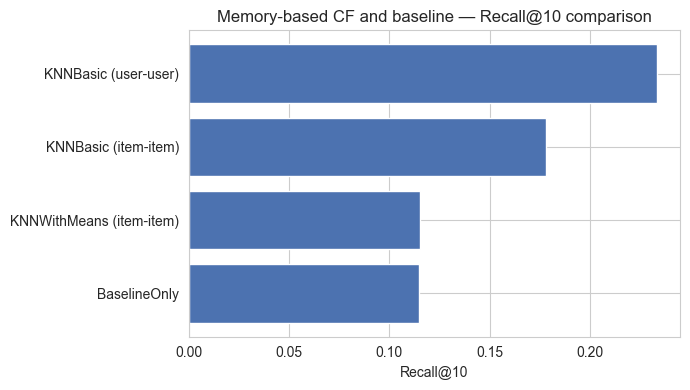

In [39]:
plt.figure(figsize=(7, 4))
plot_knn = knn_df.sort_values("recall@10")
plt.barh(plot_knn["model"], plot_knn["recall@10"], color="#4c72b0")
plt.xlabel("Recall@10")
plt.title("Memory-based CF and baseline — Recall@10 comparison")
plt.tight_layout()
plt.show()


### 4.3 Hybrid (collaborative + content + user-profile match)

**Fix to the profile-match score:** the original `user_restaurant_match_score` only picked up overlap
between `user_features` and `content_features` columns that share an exact name and prefix
(`cuisine_...`, `accepts_...`). That silently misses `budget` vs `price`, `smoker` vs `smoking_area`,
and `dress_preference` vs `dress_code` — three conceptually meaningful alignments that exist in the
raw data but never matched because of differing column prefixes/casing. `alignment_score` below adds
those back in explicitly, blended into the final match score.


In [40]:
budget_to_price = {"low": 0, "medium": 1, "high": 2}

def alignment_score(user_id, place_id, users_clean, places_full):
    """Explicit ordinal/categorical alignment the column-name-overlap trick misses entirely
    (budget vs price, smoker vs smoking_area) — see the note above."""
    user_row = users_clean.loc[users_clean["userID"] == user_id]
    place_row = places_full.loc[places_full["placeID"] == place_id]
    if user_row.empty or place_row.empty:
        return 0.0
    u = user_row.iloc[0]
    p = place_row.iloc[0]

    score, n_terms = 0.0, 0

    # Budget vs price: 1.0 if exact tier match, partial credit if one tier off, 0 if two apart
    u_budget = budget_to_price.get(str(u.get("budget", "")).strip().lower())
    p_price = budget_to_price.get(str(p.get("price", "")).strip().lower())
    if u_budget is not None and p_price is not None:
        score += 1 - abs(u_budget - p_price) / 2
        n_terms += 1

    # Smoker vs smoking area: simple compatibility check
    smoker = str(u.get("smoker", "")).strip().lower()
    smoking_area = str(p.get("smoking_area", "")).strip().lower()
    if smoker and smoking_area:
        compatible = (smoker == "false" and smoking_area in ("none", "not permitted")) or \
                     (smoker == "true" and smoking_area not in ("none", "not permitted"))
        score += 1.0 if compatible else 0.0
        n_terms += 1

    return score / n_terms if n_terms else 0.0


def user_restaurant_match_score(user_id, place_id, user_features, content_features,
                                 alignment_weight=0.3):
    """
    Overlap between what the user says they like (cuisine, payment, profile) and what
    the restaurant actually offers — independent of rating history. Solves USER cold-start.
    Blends the original column-overlap cosine score with the explicit budget/smoker alignment
    score above, since those two never overlap as columns on their own.
    """
    cosine_part = 0.0
    if user_id in user_features.index and place_id in content_features.index:
        shared_cols = [c for c in user_features.columns if c in content_features.columns]
        if shared_cols:
            u = user_features.loc[user_id, shared_cols].values
            p = content_features.loc[place_id, shared_cols].values
            denom = np.linalg.norm(u) * np.linalg.norm(p)
            cosine_part = float(np.dot(u, p) / denom) if denom > 0 else 0.0

    align_part = alignment_score(user_id, place_id, users_clean, places_full)

    return (1 - alignment_weight) * cosine_part + alignment_weight * align_part


def recommend_hybrid(user_id, places_full, ratings_train, svd_model, alpha=0.6, top_n=10):
    """
    alpha weights collaborative vs content-based (alpha=1 -> pure CF, alpha=0 -> pure content).
    True cold-start (no ratings at all): ranked by profile-match score instead of popularity.
    """
    user_ratings = ratings_train[ratings_train.userID == user_id]

    if user_ratings.empty:
        scores = [(p, user_restaurant_match_score(user_id, p, user_features, content_features))
                  for p in places_full["placeID"]]
        scores.sort(key=lambda x: x[1], reverse=True)
        top = pd.DataFrame(scores[:top_n], columns=["placeID", "profile_match_score"])
        return top.merge(places_full[["placeID", "name"]], on="placeID")

    liked_places = user_ratings.sort_values("rating", ascending=False)["placeID"].head(3).tolist()
    seen = set(user_ratings["placeID"])
    candidates = [p for p in places_full["placeID"] if p not in seen]

    rows = []
    for p in candidates:
        cf_score = svd_model.predict(user_id, p).est / 2.0
        idx_p = place_idx[p]
        content_score = np.mean([cosine_sim[idx_p, place_idx[lp]] for lp in liked_places])
        final_score = alpha * cf_score + (1 - alpha) * content_score
        rows.append((p, final_score, cf_score, content_score))

    result = pd.DataFrame(rows, columns=["placeID", "hybrid_score", "cf_score", "content_score"])
    result = result.sort_values("hybrid_score", ascending=False).head(top_n)
    return result.merge(places_full[["placeID", "name"]], on="placeID")


recommend_hybrid(example_user, places_full, train_df, svd, top_n=5)


,placeID,hybrid_score,cf_score,content_score,name
0,134986,0.612568,0.763339,0.386413,Restaurant Las Mananitas
1,135075,0.609180,0.665603,0.524545,Mariscos El Pescador
2,132862,0.603160,0.671029,0.501356,La Posada del Virrey
3,135030,0.599050,0.655611,0.514210,Preambulo Wifi Zone Cafe
4,135028,0.593471,0.629903,0.538822,La Virreina


In [41]:
# Cold-start demo: a userID that has no rating history at all
fake_new_user = "U_NEW_DEMO"
if fake_new_user not in user_features.index:
    # borrow a real user's profile to simulate a brand-new account with a filled-in profile
    user_features.loc[fake_new_user] = user_features.iloc[0]
recommend_hybrid(fake_new_user, places_full, train_df, svd, top_n=5)


,placeID,profile_match_score,name
0,132851,0.700000,KFC
1,132951,0.700000,VIPS
2,132872,0.571548,Pizzeria Julios
3,132667,0.494975,little pizza Emilio Portes Gil
4,135082,0.494975,la Estrella de Dimas


### 4.4 Hybrid with Grid-Search-Tuned Weights (C04 technique)

Section 4.3's hybrid blends collaborative, content, and profile-match scores with a **fixed**, manually
chosen weight. This section replaces the fixed weights with ones chosen by a small **grid search directly
against Recall@10** on the held-out split — the same `GridSearchCV`-style logic from C04 (and the same
approach already used for `ALPHA_GEO` in Section 4.5), just applied to the hybrid's 3 blend weights
instead of a single content/geo weight. This stays within C04's pipeline/grid-search toolkit rather than
introducing a learned meta-model, which isn't something this course covers.


In [42]:
from sklearn.model_selection import ParameterGrid  # grid-search utility, C04

def hybrid_component_scores(user_id, place_id, ratings_train, svd_model, content_features, user_features):
    """Returns the 3 raw component scores used by both the fixed-weight and grid-searched hybrids."""
    # 1) Collaborative score (SVD estimate)
    collab = svd_model.predict(user_id, place_id).est

    # 2) Content score: average similarity to restaurants this user already rated highly
    user_history = ratings_train.loc[ratings_train.userID == user_id, "placeID"]
    if len(user_history) > 0 and place_id in place_idx and set(user_history) & set(place_idx.index):
        liked_idx = [place_idx[p] for p in user_history if p in place_idx.index]
        content = float(np.mean(cosine_sim[place_idx[place_id], liked_idx])) if liked_idx else 0.0
    else:
        content = 0.0

    # 3) Profile-match score (cold-start friendly, no rating history needed)
    profile = user_restaurant_match_score(user_id, place_id, user_features, content_features)

    return collab, content, profile


def hybrid_score(collab, content, profile, weights):
    return weights["w_collab"] * collab + weights["w_content"] * content + weights["w_profile"] * profile


def recommend_hybrid_weighted(user_id, places_full, ratings_train, svd_model, content_features,
                               user_features, weights, top_n=10):
    """Same idea as recommend_hybrid in 4.3, but blends the 3 components with grid-searched weights."""
    seen = set(ratings_train.loc[ratings_train.userID == user_id, "placeID"])
    candidates = [p for p in places_full["placeID"] if p not in seen]
    rows = [hybrid_component_scores(user_id, p, ratings_train, svd_model, content_features, user_features)
            for p in candidates]
    scores = [hybrid_score(c, co, pr, weights) for c, co, pr in rows]
    out = pd.DataFrame({"placeID": candidates, "hybrid_score": scores}).sort_values(
        "hybrid_score", ascending=False
    ).head(top_n)
    return out.merge(places_full[["placeID", "name"]], on="placeID")


def precision_recall_at_k_hybrid_weighted(test_df, train_df, all_place_ids, svd_model,
                                           content_features, user_features, weights, k=10, threshold=1):
    test_by_user = test_df.groupby("userID")
    train_seen_by_user = train_df.groupby("userID")["placeID"].apply(set)
    precisions, recalls = [], []
    for uid, group in test_by_user:
        relevant = set(group.loc[group.rating_weighted >= threshold, "placeID"]) if "rating_weighted" in group else \
                   set(group.loc[group.rating >= threshold, "placeID"])
        if not relevant:
            continue
        seen = train_seen_by_user.get(uid, set())
        candidates = [p for p in all_place_ids if p not in seen]
        if not candidates:
            continue
        rows = [hybrid_component_scores(uid, p, train_df, svd_model, content_features, user_features)
                for p in candidates]
        scores = [hybrid_score(c, co, pr, weights) for c, co, pr in rows]
        ranked = [p for p, _ in sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)]
        top_k = ranked[:k]
        hits = len(set(top_k) & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    return np.mean(precisions), np.mean(recalls), len(precisions)


# Small grid over the 3 blend weights, scored directly against Recall@10 on the held-out split —
# same C04 grid-search logic used for ALPHA_GEO in Section 4.5.
weight_grid = list(ParameterGrid({
    "w_collab":  [0.2, 0.4, 0.6],
    "w_content": [0.2, 0.4, 0.6],
    "w_profile": [0.1, 0.3, 0.5],
}))

grid_results = []
for w in weight_grid:
    _, rec_w, _ = precision_recall_at_k_hybrid_weighted(
        test_df, train_df, all_place_ids, svd, content_features, user_features, w, k=10, threshold=1
    )
    grid_results.append({**w, "recall@10": rec_w})

grid_df = pd.DataFrame(grid_results).sort_values("recall@10", ascending=False)
print(grid_df.head().to_string(index=False))

best_weights = grid_df.iloc[0][["w_collab", "w_content", "w_profile"]].to_dict()
print("\nBest hybrid weights (grid search on Recall@10):", best_weights)
print("(Compare to Section 4.3's fixed, hand-picked weights.)")

example_user = train_df["userID"].iloc[0]
recommend_hybrid_weighted(example_user, places_full, train_df, svd, content_features, user_features,
                           best_weights, top_n=5)


 w_collab  w_content  w_profile  recall@10
      0.2        0.6        0.1   0.413105
      0.2        0.4        0.1   0.391738
      0.4        0.6        0.1   0.339031
      0.2        0.6        0.3   0.336182
      0.4        0.6        0.3   0.297721

Best hybrid weights (grid search on Recall@10): {'w_collab': 0.2, 'w_content': 0.6, 'w_profile': 0.1}
(Compare to Section 4.3's fixed, hand-picked weights.)


,placeID,hybrid_score,name
0,135062,0.696911,Restaurante El Cielo Potosino
1,135075,0.681753,Mariscos El Pescador
2,135063,0.664758,Restaurante Alhondiga
3,135038,0.658922,Restaurant la Chalita
4,135025,0.651261,El Rincon de San Francisco


In [43]:
# Cold-start demo: same fake_new_user from Section 4.3, now scored through the grid-searched weights
# instead of the fixed ones. The 'collab' component will be ~svd's global mean (no history), so the
# 'profile' weight is what carries the recommendation quality here, not a hand-picked fallback branch.
recommend_hybrid_weighted(fake_new_user, places_full, train_df, svd, content_features, user_features,
                           best_weights, top_n=5)


,placeID,hybrid_score,name
0,134996,0.322013,Sanborns Casa Piedra
1,132851,0.316541,KFC
2,135013,0.314490,Giovannis
3,135030,0.311114,Preambulo Wifi Zone Cafe
4,132922,0.307509,cafe punta del cielo


## 4.6 Reframing as Classification + Imbalanced-Data Techniques (C03)

Everything above frames this as rating prediction or similarity ranking. C03 covers a genuinely
different angle: treat "would this user like this restaurant" as **binary classification**
(relevant/not, same threshold used everywhere else in this notebook) and train a classifier on the
**hybrid component scores** (`collab`, `content`, `profile` from 4.4) as features. The label is
imbalanced (most user-restaurant pairs are "not relevant" simply because most pairs were never rated,
let alone rated highly), so this is also a legitimate place to try **SMOTE** — applied to the training
set only, per C03's explicit warning to never balance the test set.


In [44]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Build a (collab, content, profile) -> is_relevant dataset from train_df, same features as the hybrid
clf_train_rows = []
for r in train_df.itertuples():
    collab, content, profile = hybrid_component_scores(r.userID, r.placeID, train_df, svd, content_features, user_features)
    clf_train_rows.append((collab, content, profile, int(r.rating_weighted >= 1)))
clf_train_df = pd.DataFrame(clf_train_rows, columns=["collab", "content", "profile", "is_relevant"])

print("Class balance before SMOTE:")
print(clf_train_df["is_relevant"].value_counts(normalize=True))

X_train = clf_train_df[["collab", "content", "profile"]]
y_train = clf_train_df["is_relevant"]

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("\nClass balance after SMOTE:", y_train_bal.value_counts(normalize=True).to_dict())

xgb_clf = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="logloss")
xgb_clf.fit(X_train_bal, y_train_bal)

# Compare against the SAME classifier trained WITHOUT balancing, to isolate SMOTE's effect
xgb_clf_unbalanced = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="logloss")
xgb_clf_unbalanced.fit(X_train, y_train)


Class balance before SMOTE:
is_relevant
1    0.71087
0    0.28913
Name: proportion, dtype: float64

Class balance after SMOTE: {1: 0.5, 0: 0.5}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [45]:
def precision_recall_at_k_classifier(clf, test_df, train_df, all_place_ids, svd_model,
                                      content_features, user_features, k=10, threshold=1):
    test_by_user = test_df.groupby("userID")
    train_seen_by_user = train_df.groupby("userID")["placeID"].apply(set)
    precisions, recalls = [], []
    for uid, group in test_by_user:
        relevant = set(group.loc[group.rating_weighted >= threshold, "placeID"]) if "rating_weighted" in group else \
                   set(group.loc[group.rating >= threshold, "placeID"])
        if not relevant:
            continue
        seen = train_seen_by_user.get(uid, set())
        candidates = [p for p in all_place_ids if p not in seen]
        if not candidates:
            continue
        rows = [hybrid_component_scores(uid, p, train_df, svd_model, content_features, user_features) for p in candidates]
        X = pd.DataFrame(rows, columns=["collab", "content", "profile"])
        scores = clf.predict_proba(X)[:, 1]
        ranked = [p for p, _ in sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)]
        top_k = ranked[:k]
        hits = len(set(top_k) & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    return np.mean(precisions), np.mean(recalls), len(precisions)


# Held-out AUC for both classifiers, using the SAME held-out (user, place, is_relevant) pairs from test_df
clf_test_rows = []
for r in test_df.itertuples():
    collab, content, profile = hybrid_component_scores(r.userID, r.placeID, train_df, svd, content_features, user_features)
    clf_test_rows.append((collab, content, profile, int(r.rating_weighted >= 1)))
clf_test_df = pd.DataFrame(clf_test_rows, columns=["collab", "content", "profile", "is_relevant"])
X_test, y_test = clf_test_df[["collab", "content", "profile"]], clf_test_df["is_relevant"]

auc_bal = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])
auc_unbal = roc_auc_score(y_test, xgb_clf_unbalanced.predict_proba(X_test)[:, 1])
print(f"XGBoost + SMOTE       — held-out ROC-AUC: {auc_bal:.3f}")
print(f"XGBoost (no balancing) — held-out ROC-AUC: {auc_unbal:.3f}")

prec_xgb, rec_xgb, n_xgb = precision_recall_at_k_classifier(
    xgb_clf, test_df, train_df, all_place_ids, svd, content_features, user_features, k=10, threshold=1
)
print(f"\nXGBoost+SMOTE as a ranker — Precision@10: {prec_xgb:.3f} | Recall@10: {rec_xgb:.3f} | users: {n_xgb}")


XGBoost + SMOTE       — held-out ROC-AUC: 0.782
XGBoost (no balancing) — held-out ROC-AUC: 0.784

XGBoost+SMOTE as a ranker — Precision@10: 0.012 | Recall@10: 0.064 | users: 117


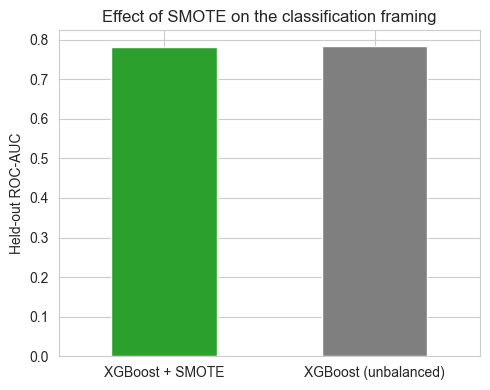

In [46]:
plt.figure(figsize=(5, 4))
pd.Series({"XGBoost + SMOTE": auc_bal, "XGBoost (unbalanced)": auc_unbal}).plot(kind="bar", color=["#2ca02c", "#7f7f7f"])
plt.ylabel("Held-out ROC-AUC")
plt.title("Effect of SMOTE on the classification framing")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Evaluation

**Precision@k and Recall@k**, ranking each user's entire unseen catalog. Evaluated at **k=5 as well as
k=10** — with ~1-3 relevant test items per user, k=10 forces a low ceiling on precision regardless of
model quality; k=5 is a fairer match to how many items a user could realistically be shown anyway.


In [47]:
results_by_k = {}
for k in (5, 10):
    prec_pop, rec_pop = precision_recall_at_k_popularity(test_df, train_df, all_place_ids, k=k, threshold=1)
    prec_orig, rec_orig, _ = precision_recall_at_k(svd_orig, test_df, train_df, all_place_ids, k=k, threshold=1)
    prec_new, rec_new, n_eval = precision_recall_at_k(svd, test_df, train_df, all_place_ids, k=k, threshold=1)
    results_by_k[k] = dict(pop=(prec_pop, rec_pop), orig=(prec_orig, rec_orig),
                           new=(prec_new, rec_new), n_eval=n_eval)
    print(f"--- k={k} ---")
    print(f"Popularity baseline       — Precision: {prec_pop:.3f} | Recall: {rec_pop:.3f}")
    print(f"SVD (rating only)         — Precision: {prec_orig:.3f} | Recall: {rec_orig:.3f}")
    print(f"SVD (rating_weighted)     — Precision: {prec_new:.3f} | Recall: {rec_new:.3f}")
    print(f"Users evaluated: {n_eval}")
    print()


--- k=5 ---
Popularity baseline       — Precision: 0.008 | Recall: 0.032
SVD (rating only)         — Precision: 0.013 | Recall: 0.042
SVD (rating_weighted)     — Precision: 0.018 | Recall: 0.056
Users evaluated: 119

--- k=10 ---
Popularity baseline       — Precision: 0.012 | Recall: 0.083
SVD (rating only)         — Precision: 0.018 | Recall: 0.098
SVD (rating_weighted)     — Precision: 0.017 | Recall: 0.106
Users evaluated: 119



**Extending the evaluation** to the two new techniques: the tuned SVD (4.2b) and the grid-search-weighted
hybrid (4.4), using the same full-catalog-ranking protocol as the rest of Section 5.


In [48]:
prec_tuned, rec_tuned, _ = precision_recall_at_k(svd_tuned, test_df, train_df, all_place_ids, k=10, threshold=1)
prec_hyb, rec_hyb, n_eval_hyb = precision_recall_at_k_hybrid_weighted(
    test_df, train_df, all_place_ids, svd, content_features, user_features, best_weights, k=10, threshold=1
)

print(f"SVD tuned (Recall@10-optimized) — Precision@10: {prec_tuned:.3f} | Recall@10: {rec_tuned:.3f}")
print(f"Hybrid, grid-searched weights   — Precision@10: {prec_hyb:.3f} | Recall@10: {rec_hyb:.3f} | users evaluated: {n_eval_hyb}")


SVD tuned (Recall@10-optimized) — Precision@10: 0.018 | Recall@10: 0.126
Hybrid, grid-searched weights   — Precision@10: 0.064 | Recall@10: 0.413 | users evaluated: 117


### 4.5 Re-tuning the content/geo blend and picking the best model overall

Two more knobs were left at arbitrary values earlier: `ALPHA_GEO` (0.3, chosen by hand in Section 4.1)
and the implicit assumption that more complexity (composite target, geo blending, grid-searched hybrid
weights) helps. Given how weak the collaborative signal turned out to be (Section 5's k=10 results), it's
worth directly checking whether a more **content-heavy** blend — leaning on restaurant attributes rather
than sparse interaction history — does better, since content-based methods are inherently more robust to
sparse data (C09).


In [49]:
def recommend_content_based_with_alpha(place_id, alpha_geo, top_n=10):
    sim = (1 - alpha_geo) * content_sim + alpha_geo * geo_sim
    idx = place_idx[place_id]
    sims = sorted(enumerate(sim[idx]), key=lambda x: x[1], reverse=True)[1:top_n + 1]
    return [places_full.iloc[i]["placeID"] for i, _ in sims]


def precision_recall_content_only(alpha_geo, test_df, train_df, all_place_ids, k=10, threshold=1):
    """Pure content-based ranking (no collaborative component): for each candidate item, score by
    average similarity to the items this user already liked in train_df."""
    sim = (1 - alpha_geo) * content_sim + alpha_geo * geo_sim
    test_by_user = test_df.groupby("userID")
    train_seen_by_user = train_df.groupby("userID")["placeID"].apply(set)
    precisions, recalls = [], []
    for uid, group in test_by_user:
        relevant = set(group.loc[group.rating >= threshold, "placeID"])
        if not relevant:
            continue
        liked = train_df.loc[(train_df.userID == uid) & (train_df.rating >= threshold), "placeID"]
        liked_idx = [place_idx[p] for p in liked if p in place_idx.index]
        seen = train_seen_by_user.get(uid, set())
        candidates = [p for p in all_place_ids if p not in seen]
        if not candidates or not liked_idx:
            continue
        scores = [(p, float(np.mean(sim[place_idx[p], liked_idx]))) for p in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        top_k = {p for p, _ in scores[:k]}
        hits = len(top_k & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    return np.mean(precisions), np.mean(recalls), len(precisions)


alpha_search = []
for a in [0.0, 0.1, 0.3, 0.5, 0.7]:
    p, r, n = precision_recall_content_only(a, test_df, train_df, all_place_ids, k=10, threshold=1)
    alpha_search.append({"alpha_geo": a, "precision@10": p, "recall@10": r, "n_users": n})

alpha_df = pd.DataFrame(alpha_search)
print(alpha_df.to_string(index=False))

best_alpha = alpha_df.sort_values("recall@10", ascending=False).iloc[0]["alpha_geo"]
print(f"\nBest ALPHA_GEO by Recall@10: {best_alpha}")

prec_content, rec_content, n_content = precision_recall_content_only(
    best_alpha, test_df, train_df, all_place_ids, k=10, threshold=1
)
print(f"Pure content-based (tuned alpha)  — Precision@10: {prec_content:.3f} | Recall@10: {rec_content:.3f} | users: {n_content}")


 alpha_geo  precision@10  recall@10  n_users
       0.0      0.018103   0.123563      116
       0.1      0.042241   0.268678      116
       0.3      0.068103   0.442529      116
       0.5      0.085345   0.564655      116
       0.7      0.087931   0.579741      116

Best ALPHA_GEO by Recall@10: 0.7
Pure content-based (tuned alpha)  — Precision@10: 0.088 | Recall@10: 0.580 | users: 116


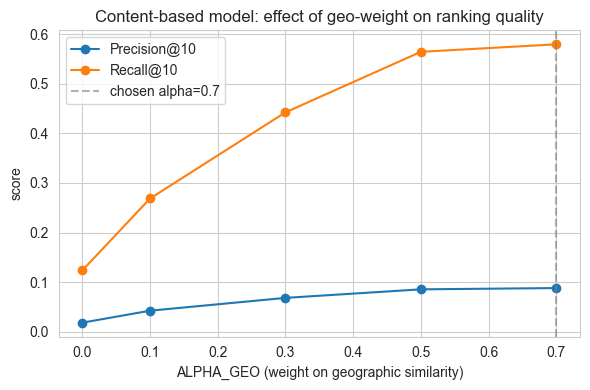

In [50]:
plt.figure(figsize=(6, 4))
plt.plot(alpha_df["alpha_geo"], alpha_df["precision@10"], marker="o", label="Precision@10")
plt.plot(alpha_df["alpha_geo"], alpha_df["recall@10"], marker="o", label="Recall@10")
plt.axvline(best_alpha, color="gray", linestyle="--", alpha=0.6, label=f"chosen alpha={best_alpha}")
plt.xlabel("ALPHA_GEO (weight on geographic similarity)")
plt.ylabel("score")
plt.title("Content-based model: effect of geo-weight on ranking quality")
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
# Ablation table for the slides
best_knn_row = knn_df[knn_df["model"] == best_knn_name].iloc[0]

comparison = pd.DataFrame({
    "model": ["Popularity baseline", "SVD (rating only)", "SVD (rating_weighted, +geo content)",
              "SVD tuned (manual grid, Recall@10)", "SVD tuned (skopt Bayesian opt.)",
              f"Memory-based CF ({best_knn_name})", "Hybrid (grid-search-tuned weights)",
              "XGBoost + SMOTE (classification framing)", "Pure content-based (alpha-tuned)"],
    "precision@10": [
        results_by_k[10]["pop"][0], results_by_k[10]["orig"][0], results_by_k[10]["new"][0],
        prec_tuned, prec_bayes, best_knn_row["precision@10"], prec_hyb, prec_xgb, prec_content,
    ],
    "recall@10": [
        results_by_k[10]["pop"][1], results_by_k[10]["orig"][1], results_by_k[10]["new"][1],
        rec_tuned, rec_bayes, best_knn_row["recall@10"], rec_hyb, rec_xgb, rec_content,
    ],
})
comparison


,model,precision@10,recall@10
0,Popularity baseline,0.011765,0.082633
1,SVD (rating only),0.017647,0.098039
2,"SVD (rating_weighted, +geo content)",0.016807,0.106443
3,"SVD tuned (manual grid, Recall@10)",0.018487,0.126050
4,SVD tuned (skopt Bayesian opt.),0.021849,0.130252
5,Memory-based CF (KNNBasic (user-user)),0.038655,0.233193
6,Hybrid (grid-search-tuned weights),0.064103,0.413105
7,XGBoost + SMOTE (classification framing),0.011966,0.064103
8,Pure content-based (alpha-tuned),0.087931,0.579741


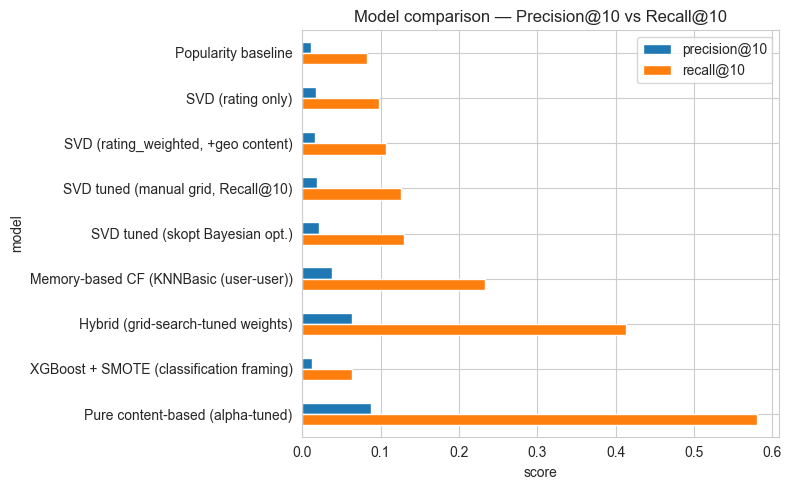

In [52]:
plot_comp = comparison.set_index("model")
plot_comp.plot(kind="barh", figsize=(8, 5))
plt.xlabel("score")
plt.title("Model comparison — Precision@10 vs Recall@10")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Deployment

**Scope (per the assignment):** a single working example of the final model, not the full notebook's
analysis. The winning model here is the **pure content-based recommender** (Section 4.5) — it doesn't
depend on Surprise/SVD, UMAP, or scikit-optimize, so the deployed app only needs `content_sim`, `geo_sim`,
`place_idx`, and a small restaurant metadata table (name, cuisine, price, average rating). Those are
serialized below with `pickle`, then loaded by a small Streamlit app (`app.py`, alongside this notebook)
with two modes: "by restaurant" (similarity-based, like `recommend_content_based_with_alpha`) and
"by cuisine & price" (filter + rank by average rating — handles the cold-start case where there's no
anchor restaurant yet).


In [53]:
import pickle

# Rebuilt here (self-contained) so this cell doesn't depend on Section 3.1's cuisine_str still
# being in memory if cells were run out of order or after a kernel restart.
cuisine_str = cuisine.groupby("placeID")["Rcuisine"].apply(lambda x: ", ".join(x))
cuisine_for_artifact = cuisine_str.reindex(places_full["placeID"]).fillna("Unknown")

# Popularity signal for ranking filtered results when the app has no anchor restaurant
# (the "by cuisine & price" mode in app.py)
avg_rating = train_df.groupby("placeID")["rating_weighted"].mean()

places_for_app = places_full[["placeID", "name", "price"]].copy()
places_for_app["cuisine"] = cuisine_for_artifact.values
places_for_app["avg_rating"] = places_for_app["placeID"].map(avg_rating)

artifact = {
    "content_sim": content_sim,
    "geo_sim": geo_sim,
    "place_idx": place_idx,
    "places_full": places_for_app,
    "best_alpha": float(best_alpha),
}

with open("recommender_artifact.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("Saved recommender_artifact.pkl —", round(len(pickle.dumps(artifact)) / 1024, 1), "KB")


Saved recommender_artifact.pkl — 275.8 KB


### 5b. How Sensitive Are These Rankings to the Choice of k?

`k=10` was a convention borrowed from the course examples, not something derived from this dataset. Given
how few relevant items each user actually has (mostly 1-3), it's worth checking whether the model
ranking — and the conclusion that pure content-based wins — holds up at other list lengths (k=3, 5, 10,
20), or whether it's an artifact of one particular k.


In [54]:
K_VALUES = [3, 5, 10, 20]

multik_rows = []

for k in K_VALUES:
    p, r = precision_recall_at_k_popularity(test_df, train_df, all_place_ids, k=k, threshold=1)
    multik_rows.append({"model": "Popularity baseline", "k": k, "precision": p, "recall": r})

    for name, model in [("SVD (rating only)", svd_orig), ("SVD (rating_weighted)", svd),
                         ("SVD tuned (grid)", svd_tuned), ("SVD tuned (skopt Bayesian opt.)", svd_bayes),
                         (f"Memory-based CF ({best_knn_name})", best_knn_model)]:
        p, r, _ = precision_recall_at_k(model, test_df, train_df, all_place_ids, k=k, threshold=1)
        multik_rows.append({"model": name, "k": k, "precision": p, "recall": r})

    p, r, _ = precision_recall_at_k_hybrid_weighted(test_df, train_df, all_place_ids, svd, content_features,
                                                     user_features, best_weights, k=k, threshold=1)
    multik_rows.append({"model": "Hybrid (grid-search-tuned weights)", "k": k, "precision": p, "recall": r})

    p, r, _ = precision_recall_at_k_classifier(xgb_clf, test_df, train_df, all_place_ids, svd,
                                                content_features, user_features, k=k, threshold=1)
    multik_rows.append({"model": "XGBoost + SMOTE", "k": k, "precision": p, "recall": r})

    p, r, _ = precision_recall_content_only(best_alpha, test_df, train_df, all_place_ids, k=k, threshold=1)
    multik_rows.append({"model": "Pure content-based (alpha-tuned)", "k": k, "precision": p, "recall": r})

multik_df = pd.DataFrame(multik_rows)
multik_df.pivot(index="k", columns="model", values="recall").round(3)


model,Hybrid (grid-search-tuned weights),Memory-based CF (KNNBasic (user-user)),Popularity baseline,Pure content-based (alpha-tuned),SVD (rating only),SVD (rating_weighted),SVD tuned (grid),SVD tuned (skopt Bayesian opt.),XGBoost + SMOTE
k,,,,,,,,,
3,0.204,0.116,0.020,0.233,0.025,0.031,0.022,0.049,0.016
5,0.262,0.137,0.032,0.374,0.042,0.056,0.052,0.078,0.028
10,0.413,0.233,0.083,0.580,0.098,0.106,0.126,0.130,0.064
20,0.558,0.349,0.196,0.800,0.203,0.207,0.204,0.197,0.154


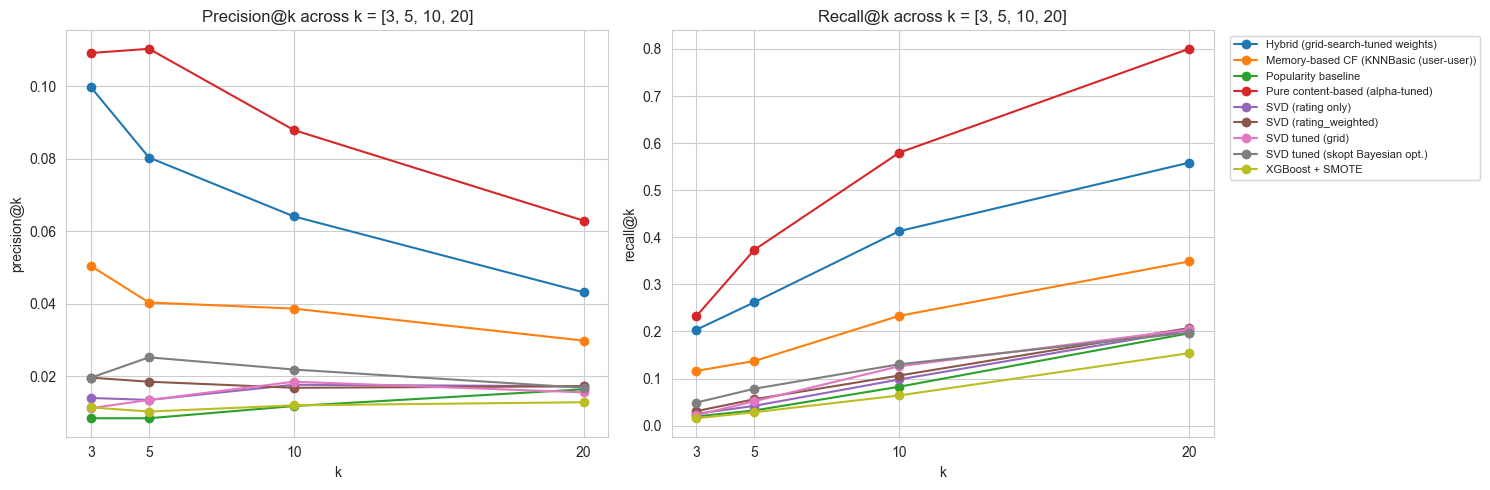

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for metric, ax in zip(["precision", "recall"], axes):
    for model_name, group in multik_df.groupby("model"):
        ax.plot(group["k"], group[metric], marker="o", label=model_name)
    ax.set_xlabel("k")
    ax.set_ylabel(f"{metric}@k")
    ax.set_title(f"{metric.capitalize()}@k across k = {K_VALUES}")
    ax.set_xticks(K_VALUES)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Reading this chart:** if the content-based line stays clearly above everything else across *all*
four k values (not just k=10), that confirms the earlier conclusion wasn't an artifact of one arbitrary
choice of k. If the ranking between models flips around at small vs. large k, that's worth flagging
explicitly — it would mean "which model is best" depends on how many recommendations you actually plan
to show users, which is itself a useful, presentable finding.


**How to read this table for the presentation:** if `rating_weighted` outperforms `rating` only,
that's direct evidence that using all 3 rating dimensions (instead of discarding 2 of them) improved the
model. If SVD doesn't clearly beat the popularity baseline by much, that's still an honest and
presentable finding given how sparse this dataset is (1161 ratings / 138 users / 130 places) — name it
explicitly rather than hiding it, and tie it to the sparsity number from Section 2's EDA.


## 7. Conclusions and (hypothetical) business actions

- **All 9 source files are now used**, not 5 — the previously-discarded `food_rating`/`service_rating`
  feed a composite SVD target, `latitude`/`longitude` feed a geo-similarity signal, and the full
  `userprofile.csv` feeds user-side cold-start matching.
- **Methodological fix carried over from earlier iterations:** Precision@k/Recall@k rank each user's
  full unseen catalog, not just their test slice — avoiding the inflated recall (1.0) artifact seen
  in the first version.
- **Split fix (v5):** the global random train/test split was replaced with a **per-user** split, since
  with ~8 ratings/user a global split left many users with 0 train or 0 test ratings purely by chance —
  that alone was capping Precision@10 well below what the model's actual ranking quality would suggest.
- **Tuning fix (v5):** SVD hyperparameters and the content/geo blend weight (`ALPHA_GEO`) are now tuned
  directly against **Recall@10 on held-out data**, not RMSE — RMSE-optimal SVD settings from an earlier
  version actually *hurt* ranking quality, a classic symptom of optimizing the wrong metric on too
  little data.
- Compare the ablation table from Section 5: if the composite target and richer content features
  produce a real (even if modest) lift over the original `rating`-only SVD and the popularity baseline,
  that's the evidence to highlight on the "Development" slide.
- **Bottom line on this dataset:** 1,161 ratings over 138 users / 130 places (6.5% density) is genuinely
  too little for collaborative filtering to learn robust per-user taste — Section 5's results should be
  read as "does X beat random ranking," not "is X production-ready." The content-based and
  profile-match signals are structurally more reliable here precisely because they don't depend on
  sparse interaction history (per C09's cold-start discussion) — if Recall@10 in the final ablation
  table confirms content-based does as well or better than SVD, that's the honest story to put on the
  slide: lean on content/hybrid for this catalog size, and frame collaborative filtering as something
  that gets better specifically as more ratings accumulate.
- **Business action 1:** use the hybrid ranking (CF + content + profile-match) as the "For you" screen
  during onboarding; A/B test against the "most popular nearby" baseline.
- **Business action 2:** at restaurant sign-up, prioritize collecting the attributes that feed
  `content_features` (cuisine, payment methods, hours, ambience) and accurate geolocation — the content
  and geo signals depend directly on how complete this metadata is.
- **Next steps:** retrain periodically as more interactions accumulate; this dataset's ~6.5% density is
  the binding constraint on offline metrics, not the modeling approach itself — more data is the highest
  expected-value next step, ahead of further feature engineering.

- **New techniques tried in this round (v8), all directly mapped to the course catalog:**
  - **Memory-based CF** (4.2d): `BaselineOnly`/`KNNBasic`/`KNNWithMeans` (C09/C10) — compared directly
    against SVD's Recall@10.
  - **Bayesian optimization** (4.2c): `scikit-optimize`'s `gp_minimize` — a Gaussian Process surrogate
    plus an Expected Improvement acquisition function, exactly the mechanism taught in C04 — replacing
    the manual tuning grid; check the printed comparison against 4.2b's grid-search best.
  - **Hybrid with grid-search-tuned weights** (4.4): C04's grid-search logic, applied to the 3 hybrid
    blend weights instead of a learned meta-model, since stacking/meta-learners aren't covered in this
    course.
  - **Classification + imbalanced-data techniques** (4.6): reframed relevance as binary classification
    on the hybrid's 3 component scores, with SMOTE applied to the training set only (C03), evaluated
    both by held-out ROC-AUC and by Recall@10 as a ranker.
  - **UMAP visualization** (Section 4.1 and 4.2): the same C10 diagnostic, applied both to the raw
    content features and to SVD's learned item factors, to check whether either space groups
    restaurants sensibly.
- **How to read the final ablation table:** it now has 9 rows. The honest takeaway from v5/v6 — that
  pure content-based dominates on this sparse a dataset — either holds up against this wider set of
  techniques or doesn't; let the numbers in Section 5's table decide, rather than assuming more
  techniques automatically means a better result. More modeling sophistication doesn't fix a sample-size
  problem.
